In [11]:
from dataclasses import dataclass

from tqdm import tqdm

import orjson
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader, TensorDataset, random_split
from tqdm import tqdm, trange

from sae_java_bug.logger import logger
from sae_java_bug.sparse_autoencoders.utils import get_device


@dataclass
class VulnerabilityData:
    vulnerable: torch.Tensor
    secure: torch.Tensor


In [12]:
import glob
import orjson
import torch
from tqdm import tqdm
from sae_java_bug.sparse_autoencoders.sae_exploration import ActivationsSchema

from sae_java_bug.logger import logger
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import numpy as np
from typing import Dict, Tuple
from sklearn.model_selection import KFold

class MLP(nn.Module):
    def __init__(
        self, input_dim, output_dim=2, hidden=(128, 64), dropout=0.3, use_bn=True
    ):
        super().__init__()
        h1, h2 = hidden
        self.use_bn = use_bn

        self.fc1 = nn.Linear(input_dim, h1)
        self.bn1 = nn.BatchNorm1d(h1) if use_bn else nn.Identity()
        self.fc2 = nn.Linear(h1, h2)
        self.bn2 = nn.BatchNorm1d(h2) if use_bn else nn.Identity()
        self.fc3 = nn.Linear(h2, output_dim)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.drop(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.drop(x)

        x = self.fc3(x)  # logits
        return x

def evaluate(loader, model, device=get_device(verbose=False)):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            preds = logits.argmax(dim=1)
            all_preds.append(preds.cpu())
            all_labels.append(y.cpu())
    y_true = torch.cat(all_labels)
    y_pred = torch.cat(all_preds)
    return accuracy_score(y_true, y_pred), y_true, y_pred

def train_small_mlp_kfold(class_negative: torch.Tensor, class_positive: torch.Tensor, k=5):

    # Create labels
    vuln_labels = torch.ones(class_positive.size(0), dtype=torch.float32)
    safe_labels = torch.zeros(class_negative.size(0), dtype=torch.float32)

    all_features = torch.cat((class_positive, class_negative), dim=0).float()
    all_labels = torch.cat((vuln_labels, safe_labels), dim=0).long()

    # print("All Features Shape:", all_features.shape)
    # print("All Labels Shape:", all_labels.shape)

    dataset = TensorDataset(all_features, all_labels)

    # Initialize KFold
    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    fold = 1
    fold_acc = []

    for train_idx, test_idx in kf.split(all_features):

        # print(f"\n===== Fold {fold}/{k} =====")
        fold += 1

        train_subset = torch.utils.data.Subset(dataset, train_idx)
        test_subset  = torch.utils.data.Subset(dataset, test_idx)

        train_loader = DataLoader(train_subset, batch_size=32, shuffle=True, drop_last=True)
        test_loader  = DataLoader(test_subset, batch_size=1000, shuffle=False, drop_last=False)

        # new model per fold
        model = MLP(input_dim=all_features.size(1)).to(device)
        # activate gradients
        model.train()
        torch.set_grad_enabled(True)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

        num_epochs = 50  # often fewer needed

        for epoch in range(num_epochs):
            model.train()
            for x_batch, y_batch in train_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)

                optimizer.zero_grad()
                logits = model(x_batch)
                loss = F.cross_entropy(logits, y_batch)
                loss.backward()
                optimizer.step()

        # evaluate this fold
        acc, _, _ = evaluate(test_loader, model, device)
        fold_acc.append(acc)

    #     print(f"Fold Test Accuracy: {acc:.4f}")

    # print("\n===== K-Fold Results =====")
    # print(f"Fold Accuracies: {fold_acc}")
    # print(f"Mean Accuracy: {sum(fold_acc)/len(fold_acc):.4f}")

    return sum(fold_acc)/len(fold_acc)


device = get_device(verbose=True)

layer_scores = {}
RUN_ID = "run_20260127_044329"
RUN_ID = "run_20260127_195450" # this is the swapped operands activations
RUN_ID = "run_20260127_202722" # this is the cwes data


files = sorted(glob.glob(f"../artifacts/activations/{RUN_ID}/activations_layer_*"), key=lambda x: int(x.split("layer_")[1].split("_")[0]))

@dataclass
class VulnerabilityData:
    vulnerable: torch.Tensor
    secure: torch.Tensor


def compute_lda_fisher_scores(secure_features: torch.Tensor, vulnerable_features: torch.Tensor) -> float:
    # Create labels
    vuln_labels = torch.ones(vulnerable_features.size(0), dtype=torch.float32)
    safe_labels = torch.zeros(secure_features.size(0), dtype=torch.float32)
    all_features = torch.cat((vulnerable_features, secure_features), dim=0).float()
    all_labels = torch.cat((vuln_labels, safe_labels), dim=0).long()

    # LDA — build dataset for layer
    X = all_features.numpy()
    y = all_labels.numpy()

    # Train LDA
    lda = LinearDiscriminantAnalysis(n_components=1)
    proj = lda.fit_transform(X, y)

    vuln_proj = proj[: len(vulnerable_features)]
    safe_proj = proj[len(vulnerable_features):]

    mean_diff = vuln_proj.mean() - safe_proj.mean()
    var_sum = vuln_proj.var() + safe_proj.var()
    fisher_score = (mean_diff ** 2) / (var_sum + 1e-8)

    return float(fisher_score)


2026-01-27 20:33:28 [info     ] Getting device.                device=mps


In [13]:


FisherScoreMap: Dict[Tuple[str, str], float] = {}
ProbingDataMap: Dict[Tuple[str, str], float] = {}
from typing import List
from collections import defaultdict

all_vulnerable_features: Dict[str, List[float]] = defaultdict(list)
all_safe_features : Dict[str, List[float]] = defaultdict(list)

for activation_file in files:
    logger.info("Processing file.", file=activation_file)

    cwe_tensor_map: Dict[str, VulnerabilityData] = {}
    vulnerable_features = torch.tensor([])
    safe_features = torch.tensor([])
    
    # Loads activations.
    with open(activation_file, "r") as f: 
        for line in tqdm(f, desc="Loading", unit=" lines", total=2500):
            try:
                data = orjson.loads(line)
            except orjson.JSONDecodeError as e:
                logger.error(f"JSON decoding error: {e}")
                # skip to the next file
                break
            
            cwe = data["cwe"]
            if cwe not in cwe_tensor_map:
                cwe_tensor_map[cwe] = VulnerabilityData(
                    vulnerable=torch.tensor([]),
                    secure=torch.tensor([]),
                )

            activations = ActivationsSchema(**data)
            vuln_tensor = torch.tensor(activations.vulnerable)
            safe_tensor = torch.tensor(activations.secure)


            vulnerable_features = torch.cat(
                (vulnerable_features, vuln_tensor.unsqueeze(0)), dim=0
            )
            safe_features = torch.cat((safe_features, safe_tensor.unsqueeze(0)), dim=0)
            

            cwe_tensor_map[cwe] = VulnerabilityData(
                vulnerable=torch.cat(
                    (cwe_tensor_map[cwe].vulnerable, vuln_tensor.unsqueeze(0)), dim=0
                ),
                secure=torch.cat(
                    (cwe_tensor_map[cwe].secure, safe_tensor.unsqueeze(0)), dim=0
                ),
            )

        print("Vulnerable Features Shape:", vulnerable_features.shape , "Safe Features Shape:", safe_features.shape)
        print("CWE:", cwe, "Vulnerable Shape:", vulnerable_features.shape, "Safe Shape:", safe_features.shape)
    
        all_vulnerable_features[
            "layer_" + activation_file.split("layer_")[1].split("_")[0]
        ] = torch.tensor(vulnerable_features)
        all_safe_features[
            "layer_" + activation_file.split("layer_")[1].split("_")[0]
        ]= torch.tensor(safe_features)
        

    # Save for later reuse
    layer_id = activation_file.split("layer_")[1].split("_")[0]
    torch.save(vulnerable_features, f"../artifacts/activations/{RUN_ID}/vulnerable_layer_{layer_id}.pt")
    torch.save(safe_features, f"../artifacts/activations/{RUN_ID}/safe_layer_{layer_id}.pt")

2026-01-27 20:33:32 [info     ] Processing file.               file=../artifacts/activations/run_20260127_202722/activations_layer_0_sae_blocks.0.hook_resid_post_component_hook_resid_post.hook_sae_acts_post.jsonl


Loading:  95%|█████████▌| 2383/2500 [03:03<00:15,  7.66 lines/s]

2026-01-27 20:36:36 [error    ] JSON decoding error: unexpected end of data: line 1 column 155701 (char 155700)


Loading:  95%|█████████▌| 2383/2500 [03:03<00:09, 12.97 lines/s]
/var/folders/s4/2zl3nz4j225gfbx8fkbdv9sm0000gq/T/ipykernel_7310/3811333901.py:58: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ] = torch.tensor(vulnerable_features)
/var/folders/s4/2zl3nz4j225gfbx8fkbdv9sm0000gq/T/ipykernel_7310/3811333901.py:61: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ]= torch.tensor(safe_features)


Vulnerable Features Shape: torch.Size([2383, 16384]) Safe Features Shape: torch.Size([2383, 16384])
CWE: CWE-476 Vulnerable Shape: torch.Size([2383, 16384]) Safe Shape: torch.Size([2383, 16384])


In [14]:
for key, data in tqdm(cwe_tensor_map.items()):
    # Compute LDA Fisher Score for this layer and CWE
    fisher_score = compute_lda_fisher_scores(data.secure, data.vulnerable)
    # logger.info(f"  LDA Fisher Score for CWE {key}: {fisher_score:.4f}")
    FisherScoreMap[(layer_id, key)] = fisher_score
    probe_score = train_small_mlp_kfold(data.secure, data.vulnerable, k=5)
    ProbingDataMap[(layer_id, key)] = probe_score


fisher_score = compute_lda_fisher_scores(safe_features, vulnerable_features)
FisherScoreMap[(layer_id, "ALL")] = fisher_score

100%|██████████| 25/25 [03:22<00:00,  8.10s/it]


In [18]:
FisherScoreMap

{('0', 'CWE-200'): 25.795289649956906,
 ('0', 'CWE-400'): 46.516385911549825,
 ('0', 'CWE-125'): 113.13271030561204,
 ('0', 'CWE-416'): 7.055609738227705,
 ('0', 'CWE-89'): 9.473184065351631,
 ('0', 'CWE-20'): 19.81509614159655,
 ('0', 'CWE-369'): 27.117368896728863,
 ('0', 'CWE-78'): 16.286262635150887,
 ('0', 'CWE-190'): 9.873783135084993,
 ('0', 'CWE-79'): 14.193112559253576,
 ('0', 'CWE-787'): 176.53394685058342,
 ('0', 'CWE-352'): 25.290492207617955,
 ('0', 'CWE-22'): 7.835503993240612,
 ('0', 'CWE-94'): 12.564407684757482,
 ('0', 'CWE-362'): 8.005993456748742,
 ('0', 'CWE-287'): 22.032203990631295,
 ('0', 'CWE-120'): 19.08885895800825,
 ('0', 'CWE-476'): 85.46323650819372,
 ('0', 'CWE-434'): 58.000106828288736,
 ('0', 'CWE-401'): 8.544435575734719,
 ('0', 'CWE-119'): 160.06584778445549,
 ('0', 'CWE-415'): 11.953215820807113,
 ('0', 'CWE-189'): 5.748840966505891,
 ('0', 'CWE-264'): 14.426864327860436,
 ('0', 'CWE-399'): 32.5295674047461,
 ('0', 'ALL'): 5.145404659366511}

2026-01-28 04:37:53 [info     ] Layer 0, CWE CWE-200: LDA Fisher Score = 25.7953, Probing Accuracy = 0.2994


Loading:  92%|█████████▏| 2312/2500 [00:02<00:00, 1065.35 lines/s]

2026-01-28 04:37:56 [error    ] JSON decoding error: unexpected end of data: line 1 column 155701 (char 155700)


Loading:  95%|█████████▌| 2383/2500 [00:02<00:00, 847.16 lines/s] 


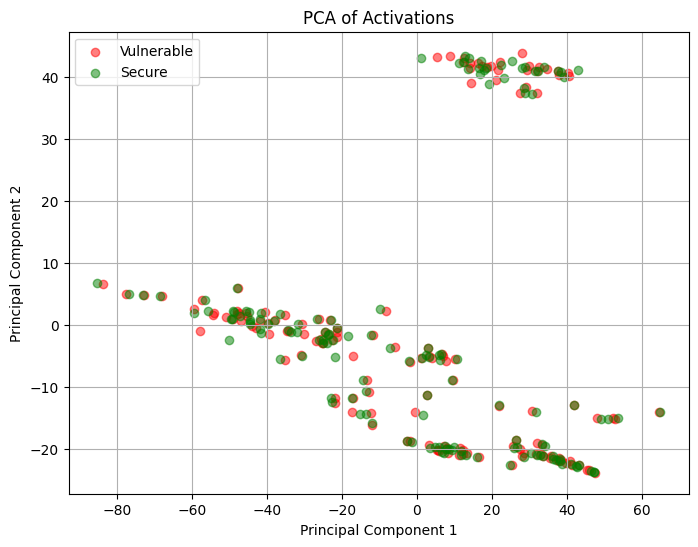

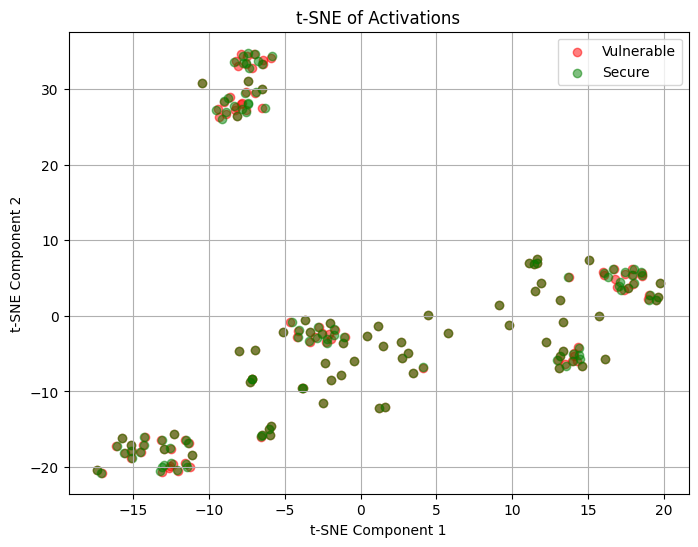

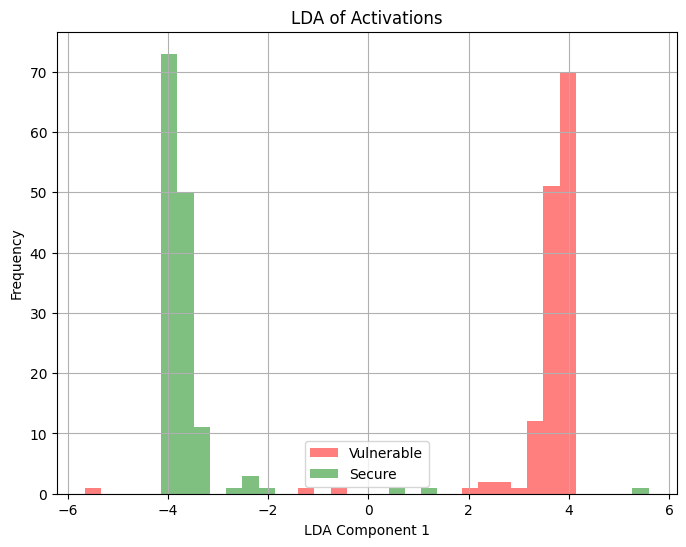

2026-01-28 04:37:57 [info     ] Layer 0, CWE CWE-400: LDA Fisher Score = 46.5164, Probing Accuracy = 0.1769


Loading:  93%|█████████▎| 2314/2500 [00:02<00:00, 1073.03 lines/s]

2026-01-28 04:38:00 [error    ] JSON decoding error: unexpected end of data: line 1 column 155701 (char 155700)


Loading:  95%|█████████▌| 2383/2500 [00:02<00:00, 1029.28 lines/s]


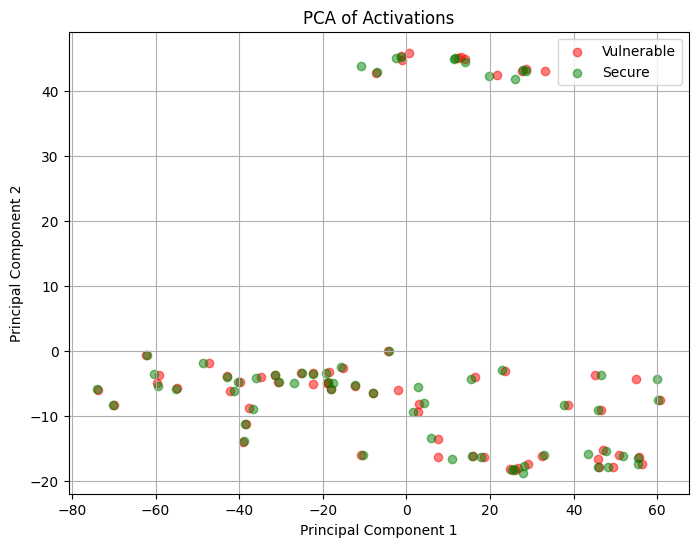

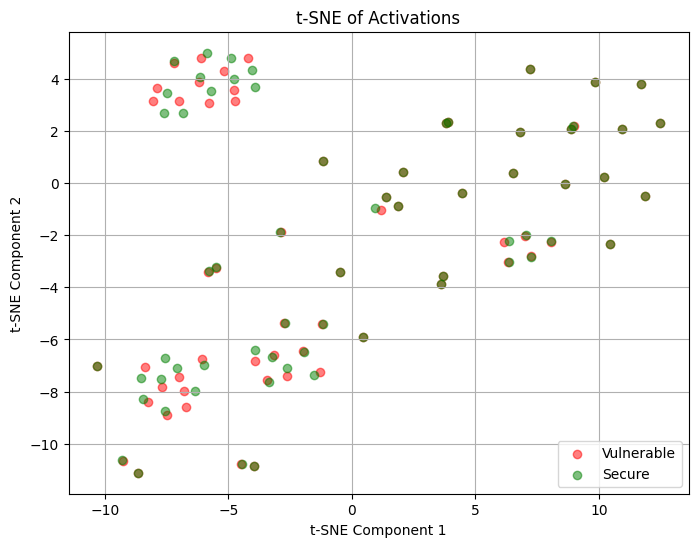

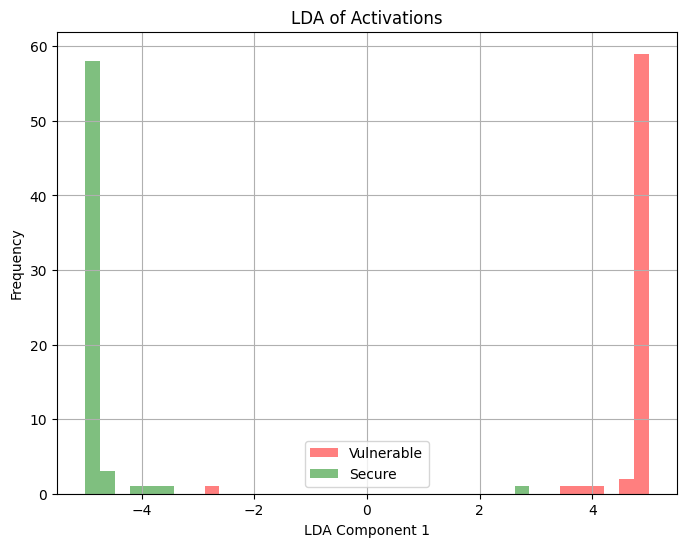

2026-01-28 04:38:01 [info     ] Layer 0, CWE CWE-125: LDA Fisher Score = 113.1327, Probing Accuracy = 0.2137


Loading:  95%|█████████▍| 2366/2500 [00:03<00:00, 639.02 lines/s] 

2026-01-28 04:38:04 [error    ] JSON decoding error: unexpected end of data: line 1 column 155701 (char 155700)


Loading:  95%|█████████▌| 2383/2500 [00:03<00:00, 769.54 lines/s]


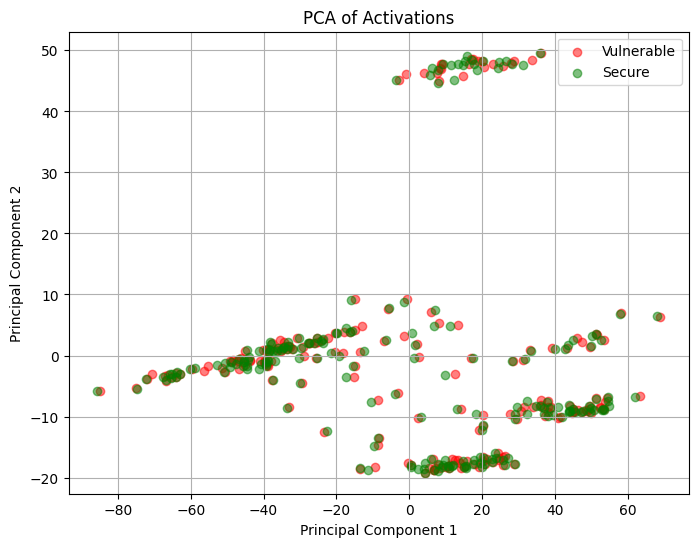

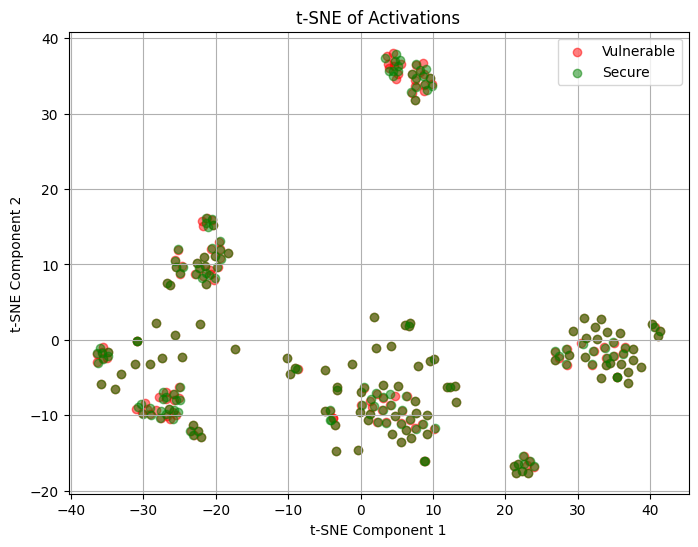

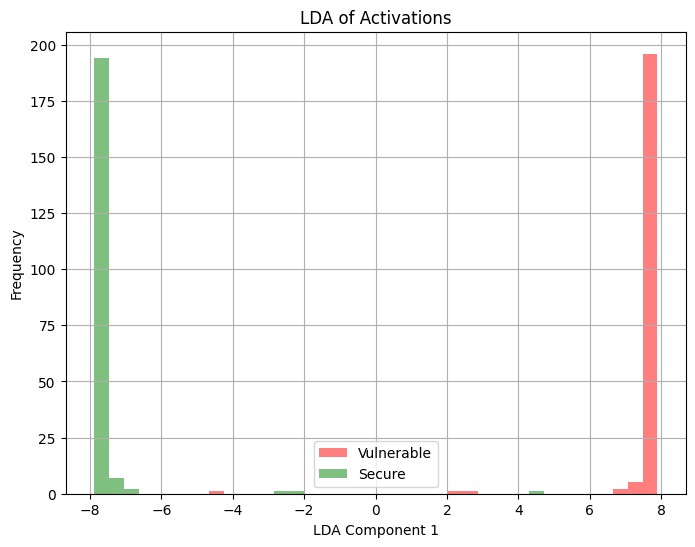

2026-01-28 04:38:05 [info     ] Layer 0, CWE CWE-416: LDA Fisher Score = 7.0556, Probing Accuracy = 0.2052


Loading:  95%|█████████▌| 2377/2500 [00:02<00:00, 889.15 lines/s] 

2026-01-28 04:38:08 [error    ] JSON decoding error: unexpected end of data: line 1 column 155701 (char 155700)


Loading:  95%|█████████▌| 2383/2500 [00:02<00:00, 972.03 lines/s]


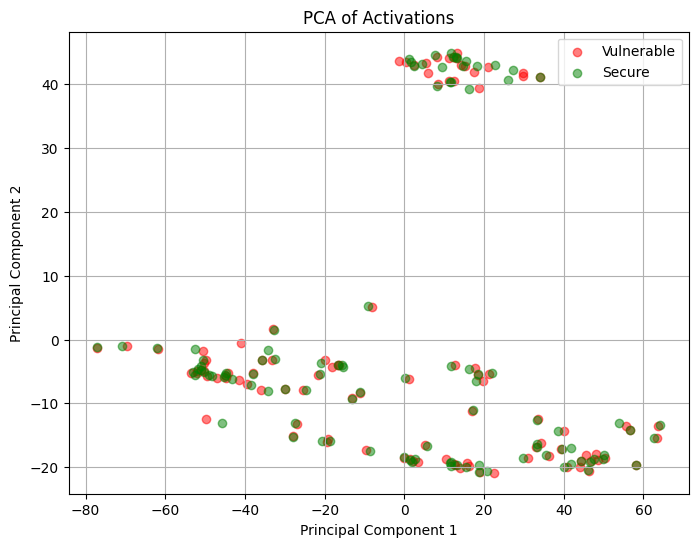

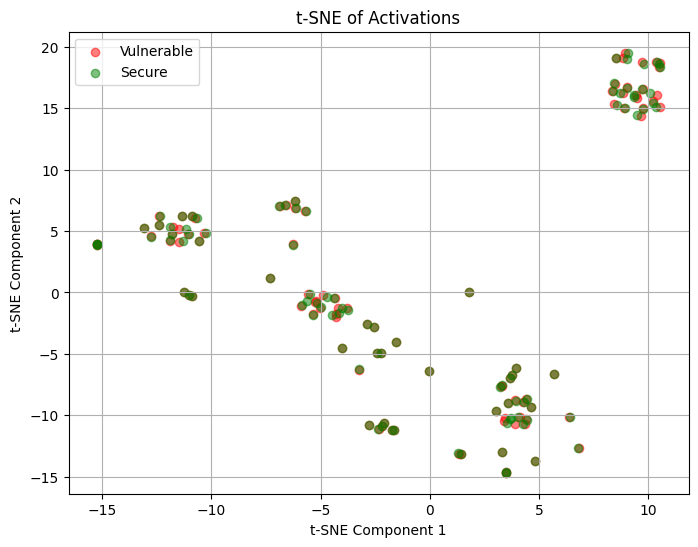

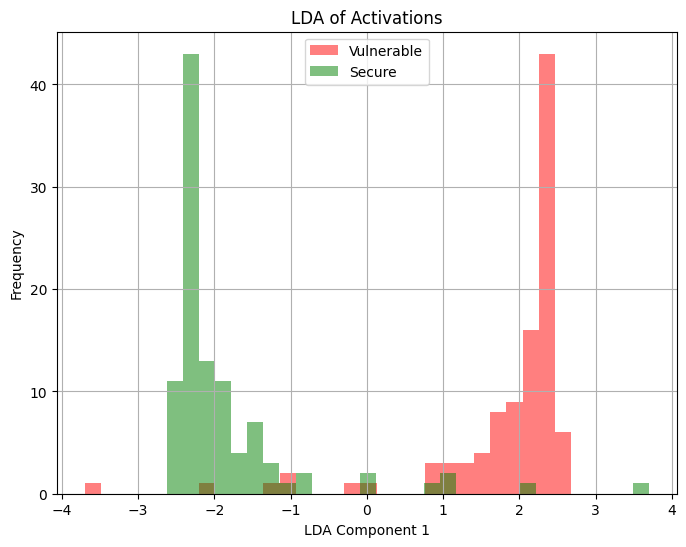

2026-01-28 04:38:09 [info     ] Layer 0, CWE CWE-89: LDA Fisher Score = 9.4732, Probing Accuracy = 0.1632


Loading:  92%|█████████▏| 2294/2500 [00:02<00:00, 1059.52 lines/s]

2026-01-28 04:38:11 [error    ] JSON decoding error: unexpected end of data: line 1 column 155701 (char 155700)


Loading:  95%|█████████▌| 2383/2500 [00:02<00:00, 1007.89 lines/s]


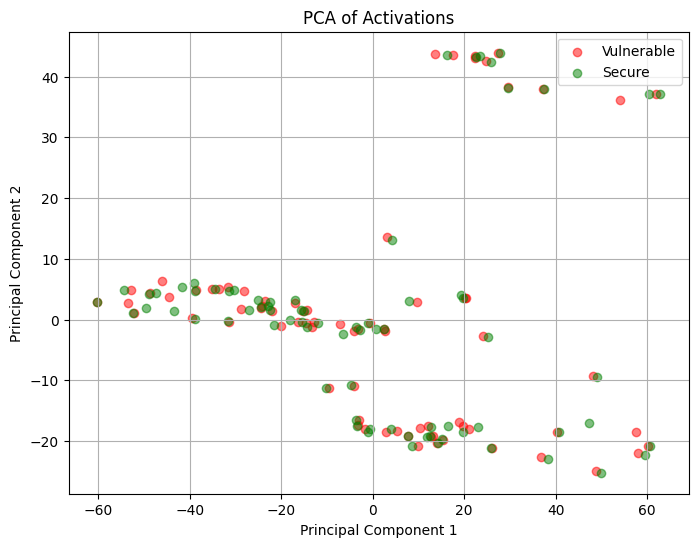

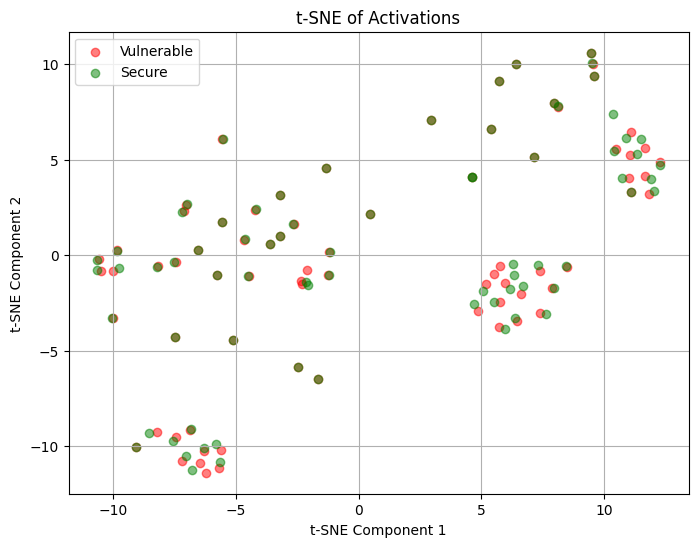

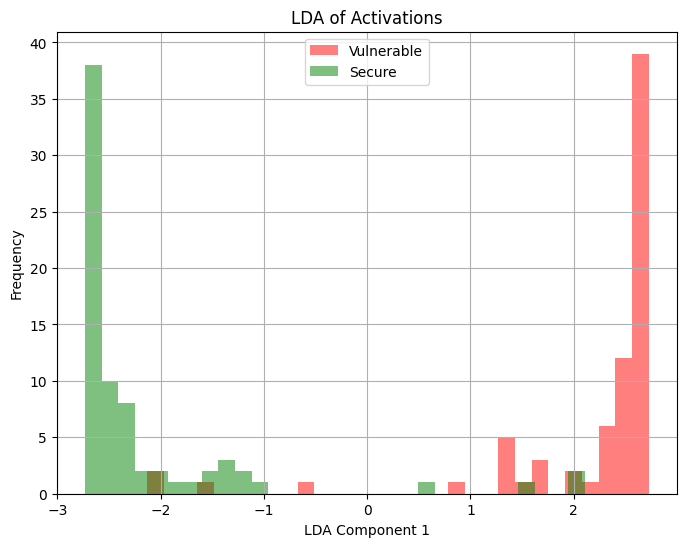

2026-01-28 04:38:12 [info     ] Layer 0, CWE CWE-20: LDA Fisher Score = 19.8151, Probing Accuracy = 0.2707


Loading:  95%|█████████▌| 2375/2500 [00:02<00:00, 981.30 lines/s]

2026-01-28 04:38:15 [error    ] JSON decoding error: unexpected end of data: line 1 column 155701 (char 155700)


Loading:  95%|█████████▌| 2383/2500 [00:02<00:00, 862.65 lines/s]


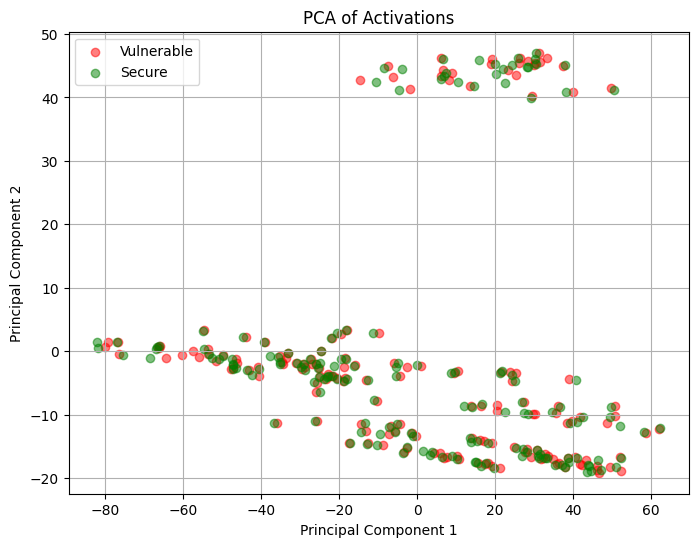

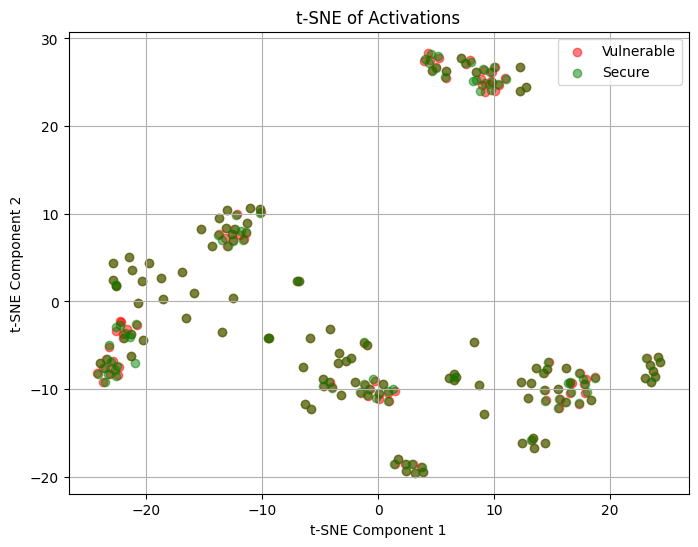

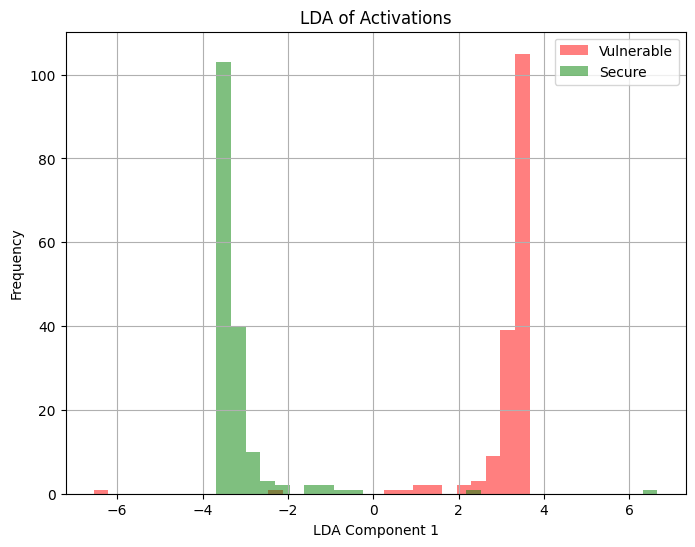

2026-01-28 04:38:17 [info     ] Layer 0, CWE CWE-369: LDA Fisher Score = 27.1174, Probing Accuracy = 0.3385


Loading:  92%|█████████▏| 2297/2500 [00:02<00:00, 1064.11 lines/s]

2026-01-28 04:38:19 [error    ] JSON decoding error: unexpected end of data: line 1 column 155701 (char 155700)


Loading:  95%|█████████▌| 2383/2500 [00:02<00:00, 1011.95 lines/s]


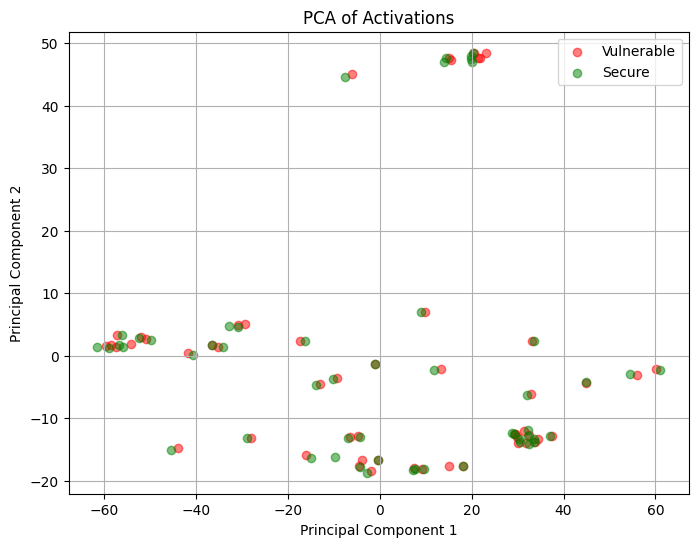

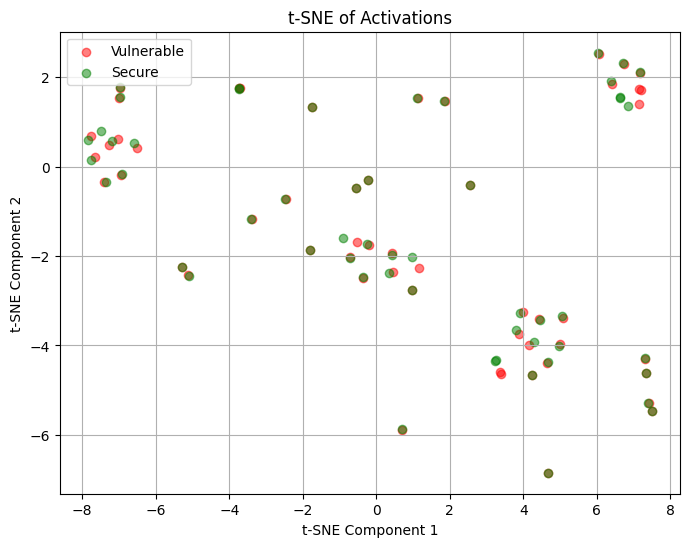

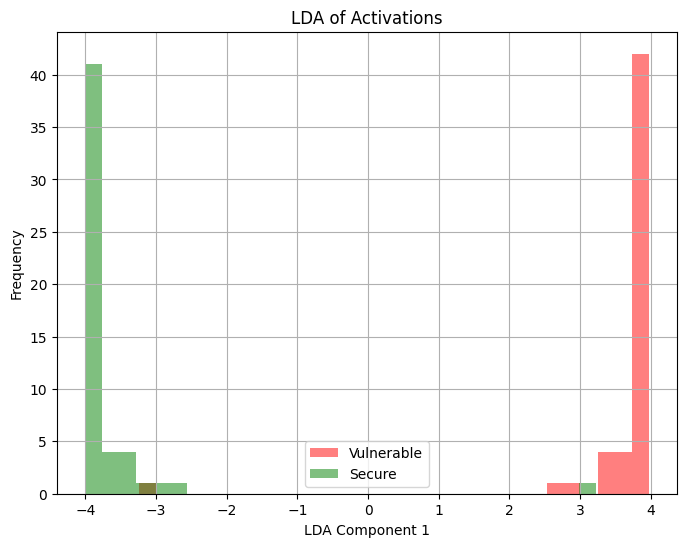

2026-01-28 04:38:20 [info     ] Layer 0, CWE CWE-78: LDA Fisher Score = 16.2863, Probing Accuracy = 0.3229


Loading:  93%|█████████▎| 2314/2500 [00:02<00:00, 1105.35 lines/s]

2026-01-28 04:38:23 [error    ] JSON decoding error: unexpected end of data: line 1 column 155701 (char 155700)


Loading:  95%|█████████▌| 2383/2500 [00:02<00:00, 1038.11 lines/s]


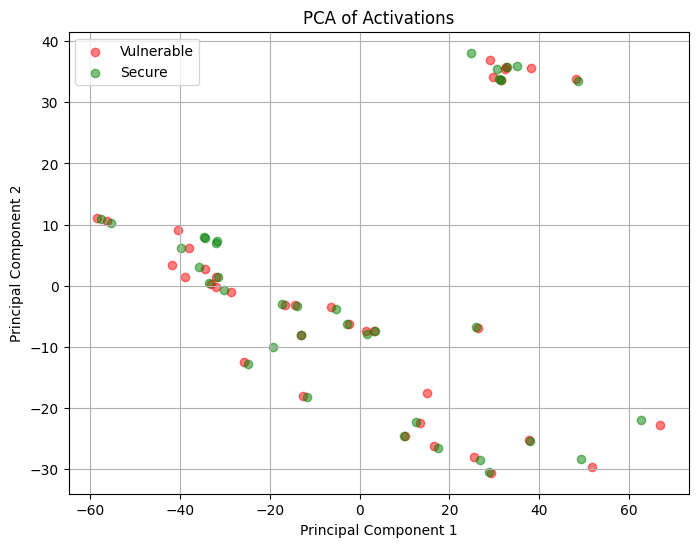

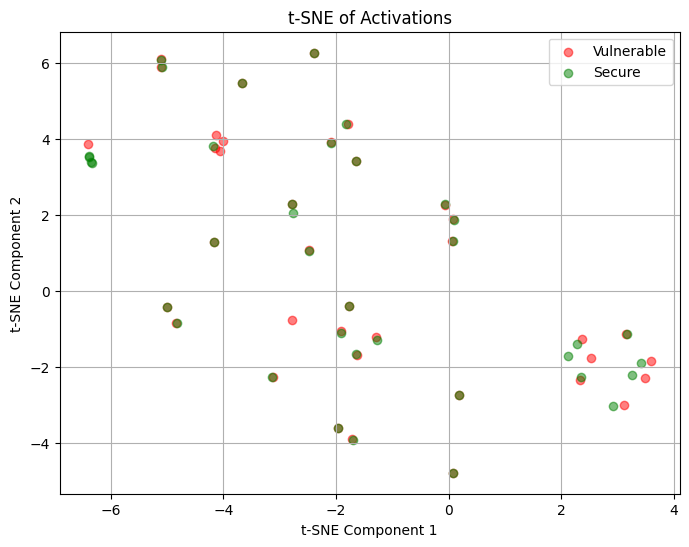

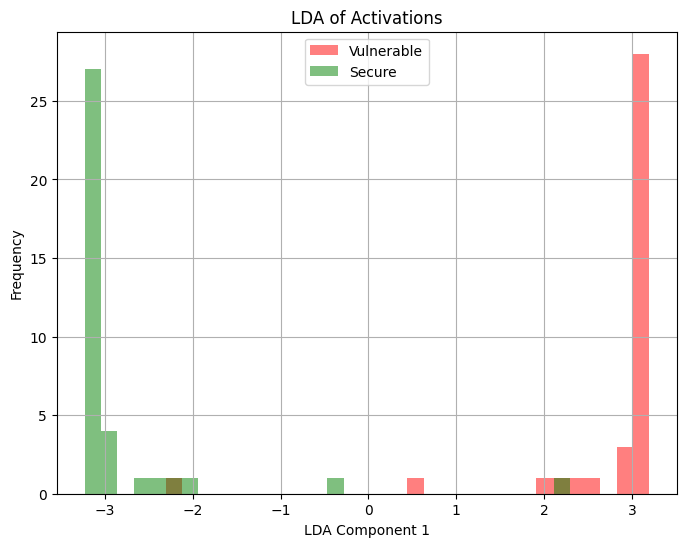

2026-01-28 04:38:23 [info     ] Layer 0, CWE CWE-190: LDA Fisher Score = 9.8738, Probing Accuracy = 0.2722


Loading:  92%|█████████▏| 2307/2500 [00:02<00:00, 981.13 lines/s] 

2026-01-28 04:38:26 [error    ] JSON decoding error: unexpected end of data: line 1 column 155701 (char 155700)


Loading:  95%|█████████▌| 2383/2500 [00:02<00:00, 994.60 lines/s]


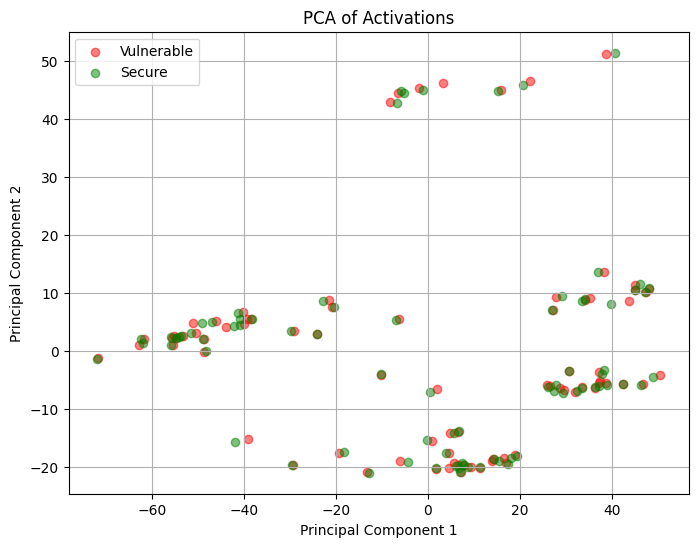

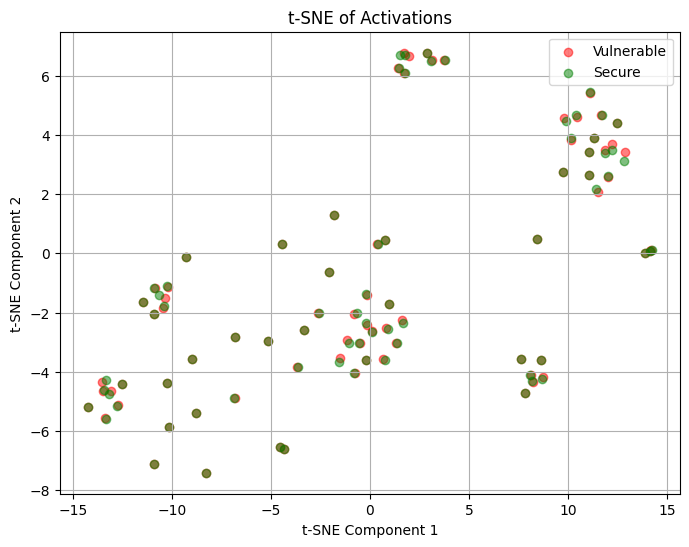

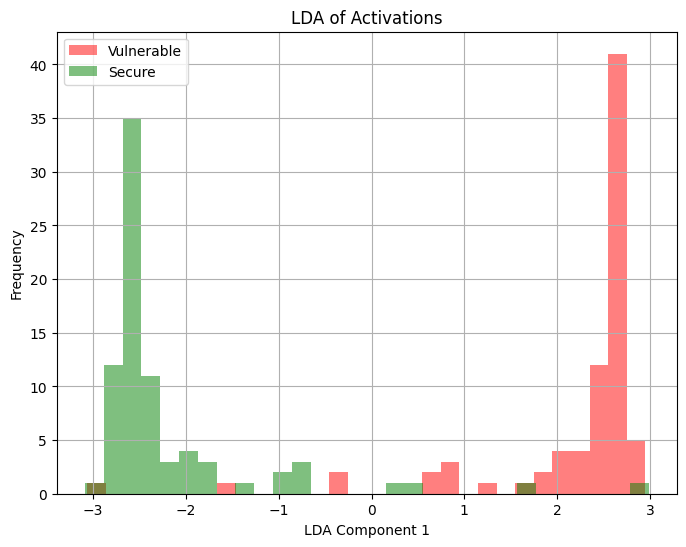

2026-01-28 04:38:27 [info     ] Layer 0, CWE CWE-79: LDA Fisher Score = 14.1931, Probing Accuracy = 0.2656


Loading:  94%|█████████▎| 2342/2500 [00:03<00:00, 553.95 lines/s]

2026-01-28 04:38:31 [error    ] JSON decoding error: unexpected end of data: line 1 column 155701 (char 155700)


Loading:  95%|█████████▌| 2383/2500 [00:03<00:00, 652.52 lines/s]


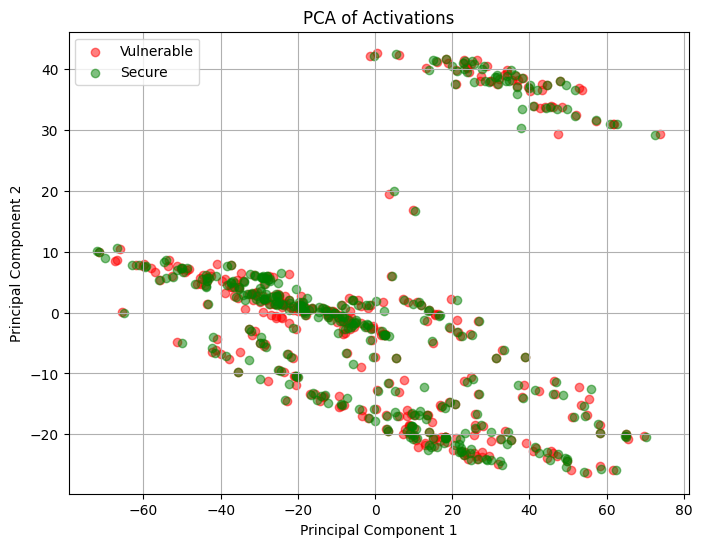

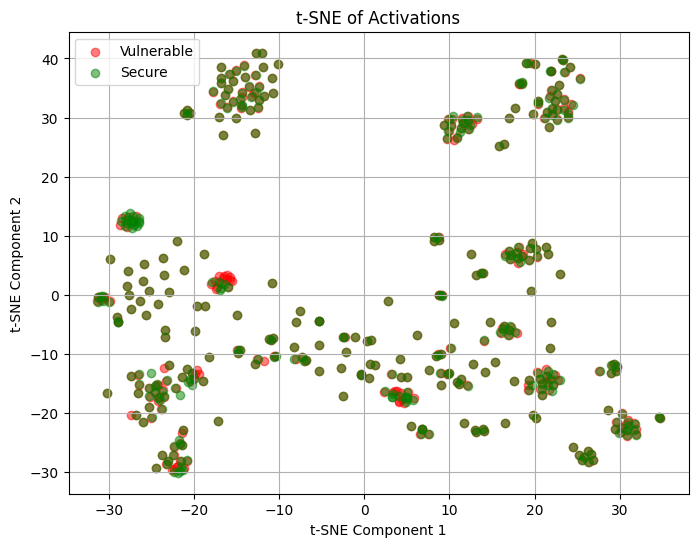

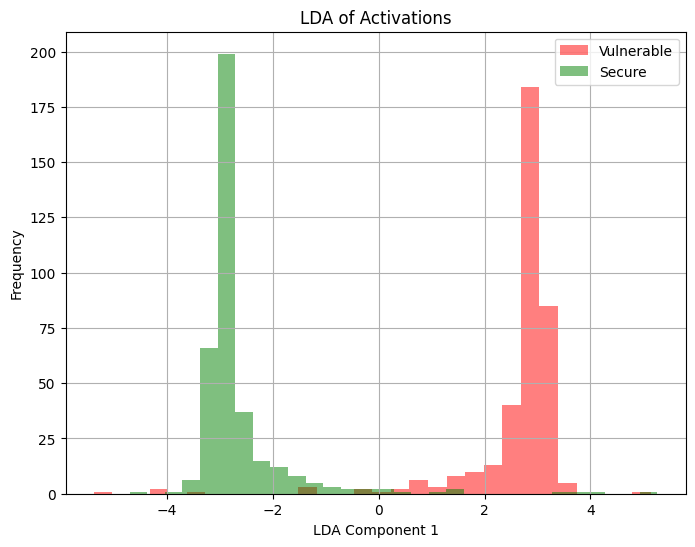

2026-01-28 04:38:34 [info     ] Layer 0, CWE CWE-787: LDA Fisher Score = 176.5339, Probing Accuracy = 0.2387


Loading:  95%|█████████▍| 2365/2500 [00:02<00:00, 722.12 lines/s] 

2026-01-28 04:38:36 [error    ] JSON decoding error: unexpected end of data: line 1 column 155701 (char 155700)


Loading:  95%|█████████▌| 2383/2500 [00:02<00:00, 889.38 lines/s]


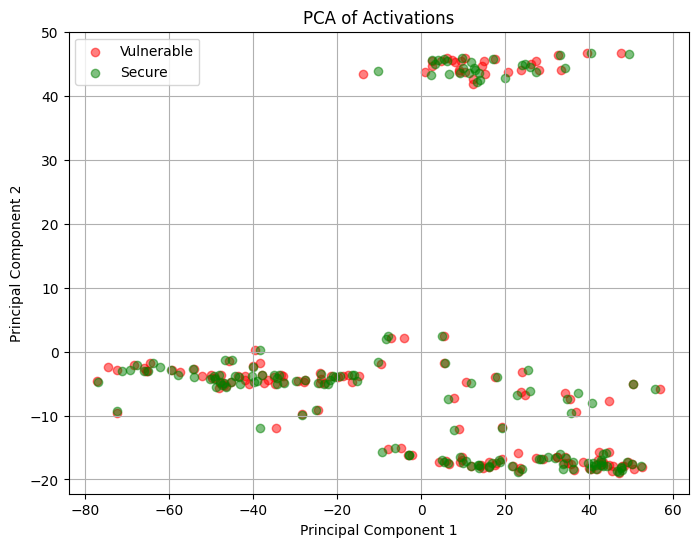

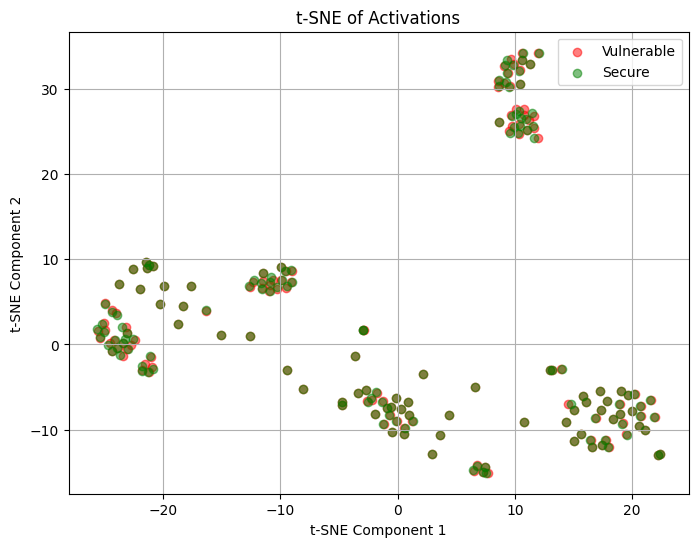

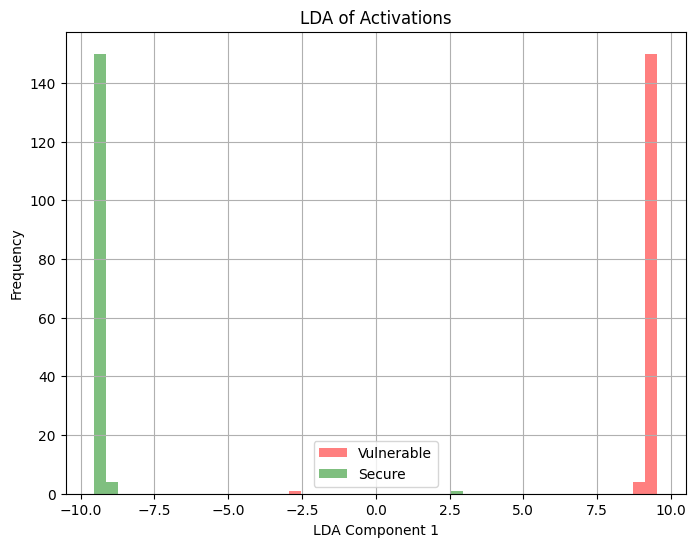

2026-01-28 04:38:38 [info     ] Layer 0, CWE CWE-352: LDA Fisher Score = 25.2905, Probing Accuracy = 0.0833


Loading:  95%|█████████▍| 2366/2500 [00:02<00:00, 1109.40 lines/s]

2026-01-28 04:38:40 [error    ] JSON decoding error: unexpected end of data: line 1 column 155701 (char 155700)


Loading:  95%|█████████▌| 2383/2500 [00:02<00:00, 1084.75 lines/s]


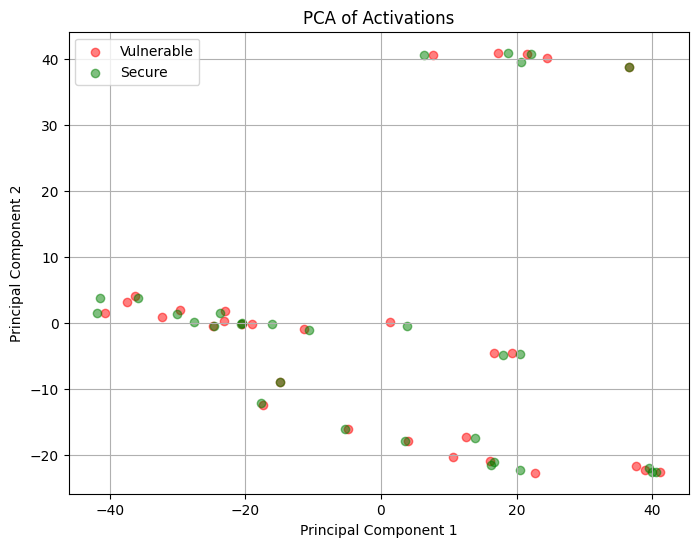

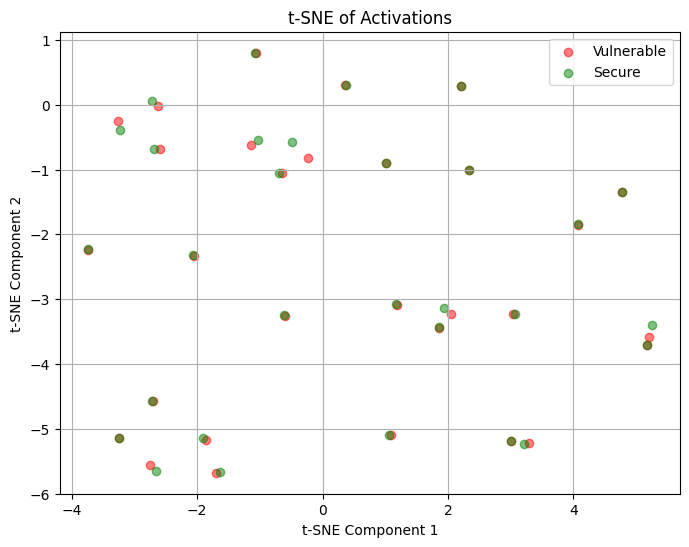

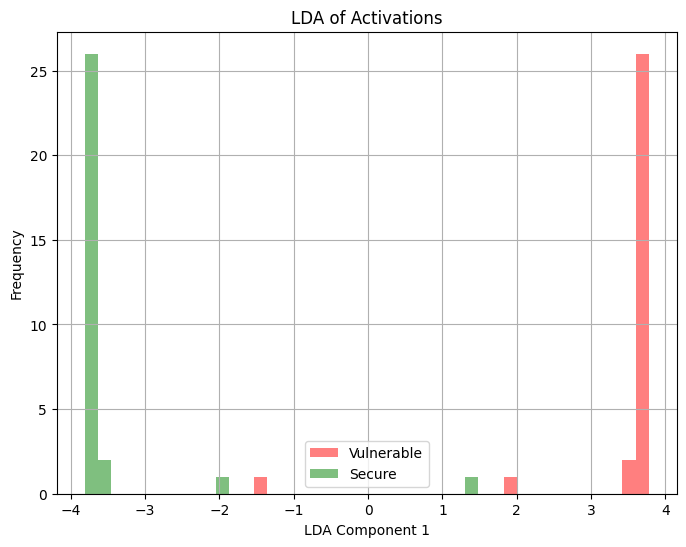

2026-01-28 04:38:41 [info     ] Layer 0, CWE CWE-22: LDA Fisher Score = 7.8355, Probing Accuracy = 0.2051


Loading:  91%|█████████▏| 2282/2500 [00:02<00:00, 1016.65 lines/s]

2026-01-28 04:38:43 [error    ] JSON decoding error: unexpected end of data: line 1 column 155701 (char 155700)


Loading:  95%|█████████▌| 2383/2500 [00:02<00:00, 1031.80 lines/s]


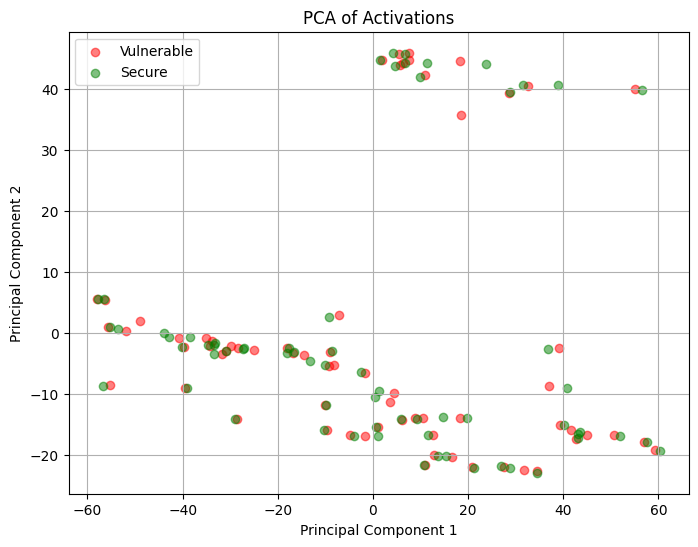

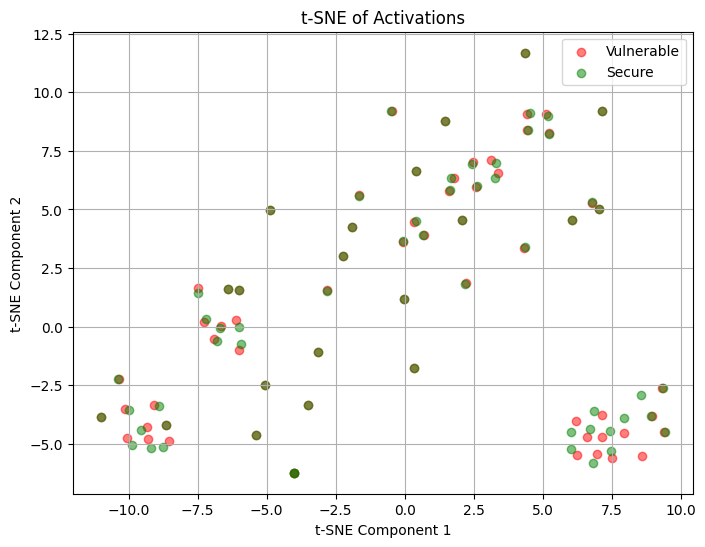

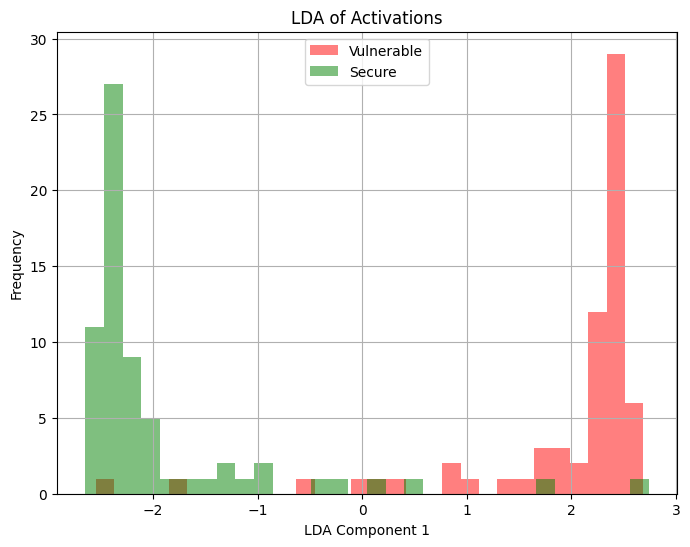

2026-01-28 04:38:44 [info     ] Layer 0, CWE CWE-94: LDA Fisher Score = 12.5644, Probing Accuracy = 0.1128


Loading:  92%|█████████▏| 2305/2500 [00:02<00:00, 1121.57 lines/s]

2026-01-28 04:38:46 [error    ] JSON decoding error: unexpected end of data: line 1 column 155701 (char 155700)


Loading:  95%|█████████▌| 2383/2500 [00:02<00:00, 1084.34 lines/s]


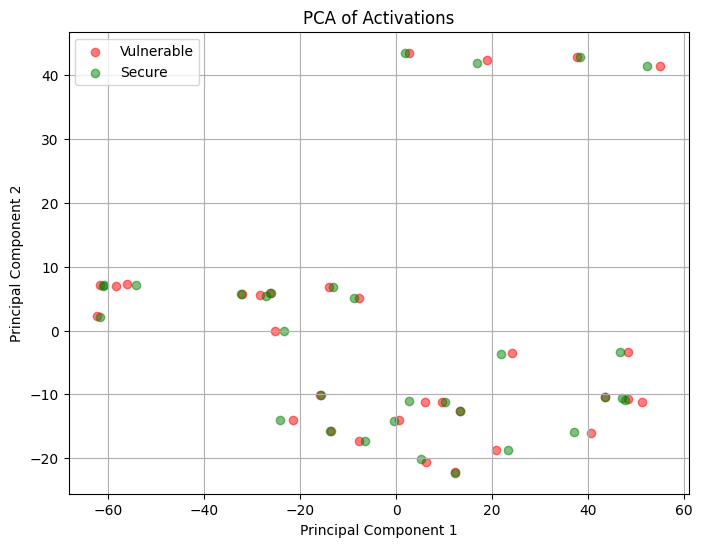

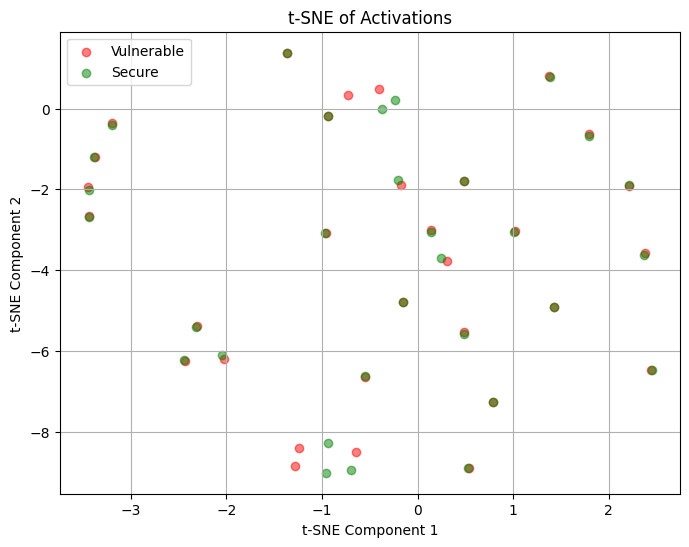

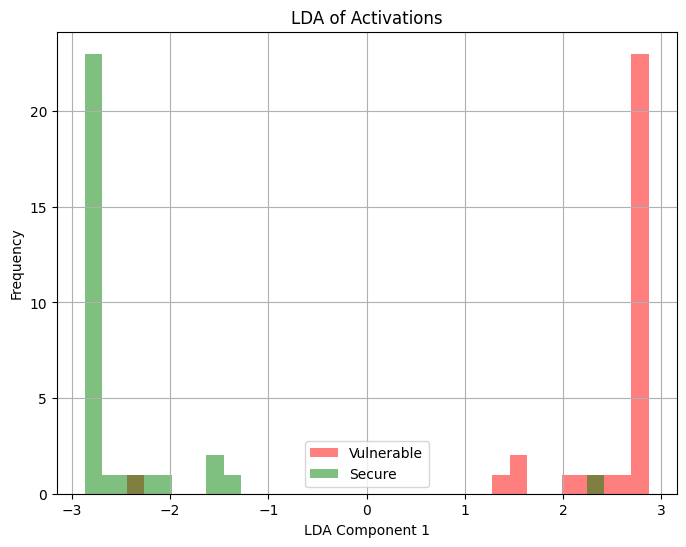

2026-01-28 04:38:47 [info     ] Layer 0, CWE CWE-362: LDA Fisher Score = 8.0060, Probing Accuracy = 0.1833


Loading:  94%|█████████▍| 2347/2500 [00:02<00:00, 1080.85 lines/s]

2026-01-28 04:38:49 [error    ] JSON decoding error: unexpected end of data: line 1 column 155701 (char 155700)


Loading:  95%|█████████▌| 2383/2500 [00:02<00:00, 1028.38 lines/s]


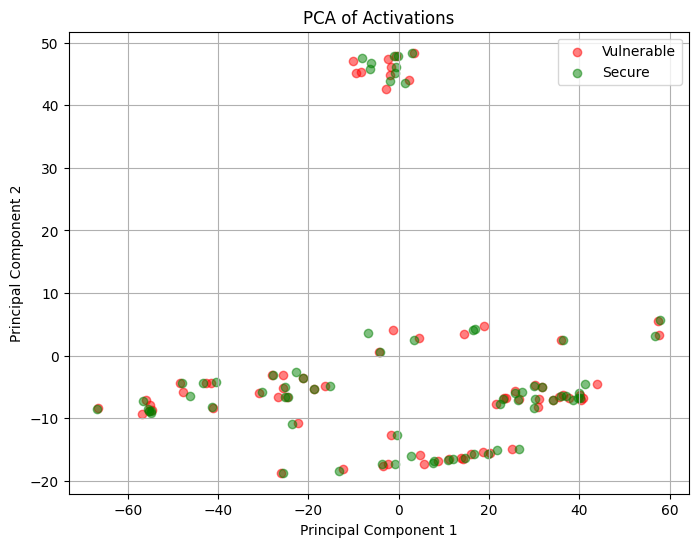

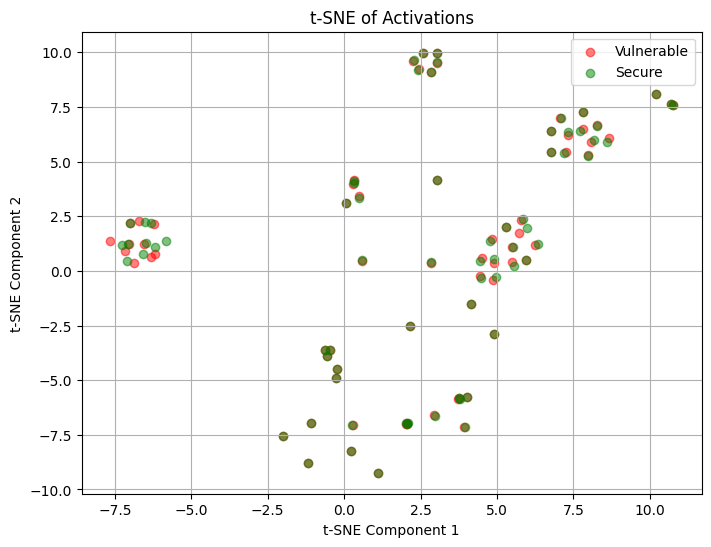

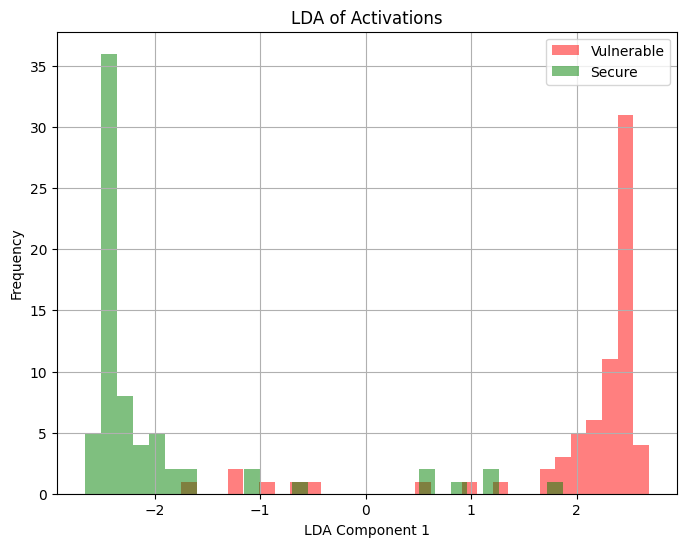

2026-01-28 04:38:50 [info     ] Layer 0, CWE CWE-287: LDA Fisher Score = 22.0322, Probing Accuracy = 0.2110


Loading:  95%|█████████▌| 2377/2500 [00:02<00:00, 1094.20 lines/s]

2026-01-28 04:38:52 [error    ] JSON decoding error: unexpected end of data: line 1 column 155701 (char 155700)


Loading:  95%|█████████▌| 2383/2500 [00:02<00:00, 1102.23 lines/s]


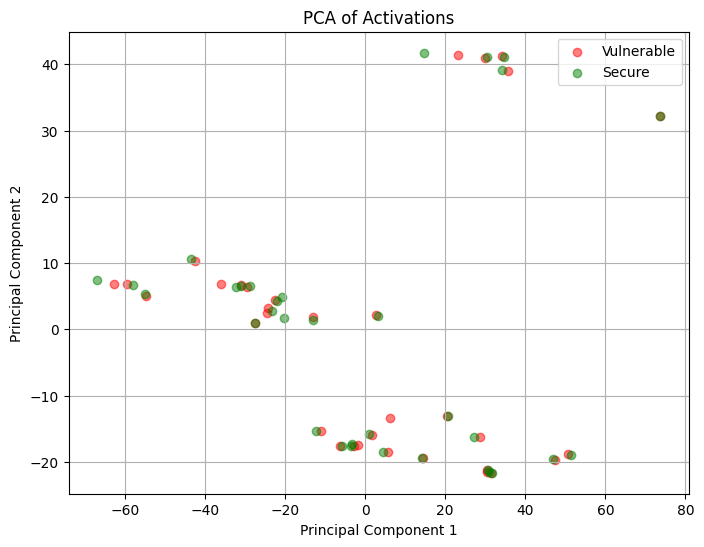

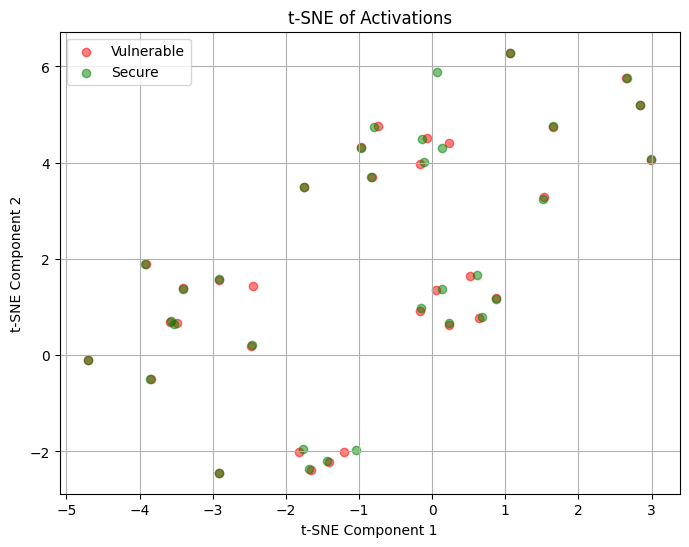

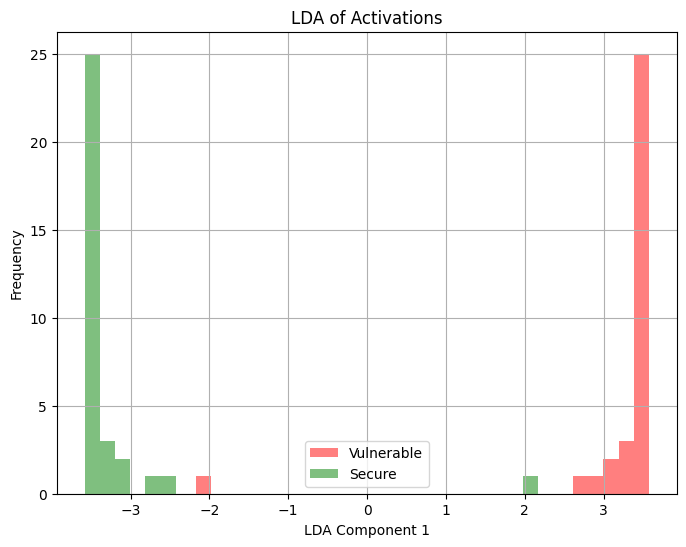

2026-01-28 04:38:53 [info     ] Layer 0, CWE CWE-120: LDA Fisher Score = 19.0889, Probing Accuracy = 0.1857


Loading:  92%|█████████▏| 2301/2500 [00:02<00:00, 1006.50 lines/s]

2026-01-28 04:38:55 [error    ] JSON decoding error: unexpected end of data: line 1 column 155701 (char 155700)


Loading:  95%|█████████▌| 2383/2500 [00:02<00:00, 1106.85 lines/s]


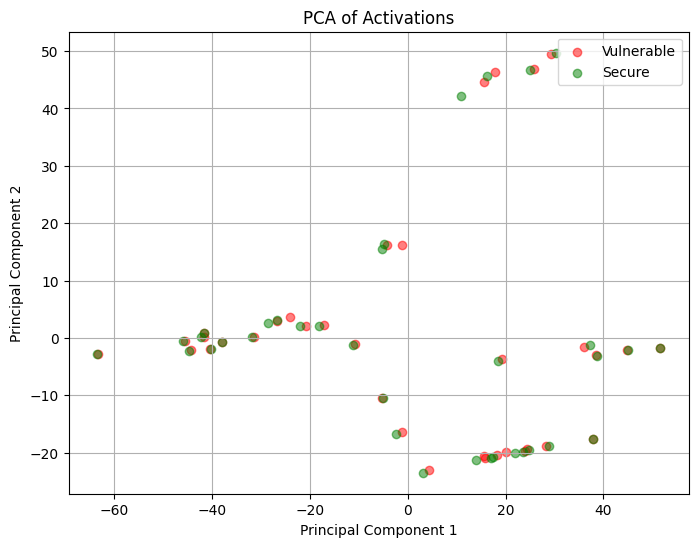

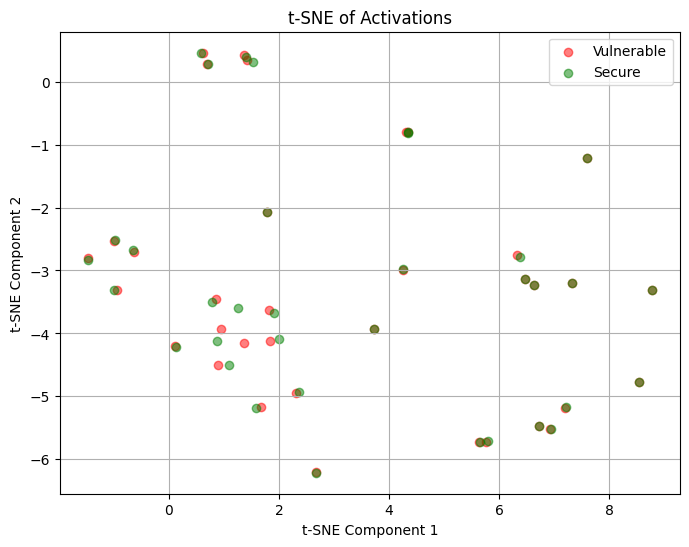

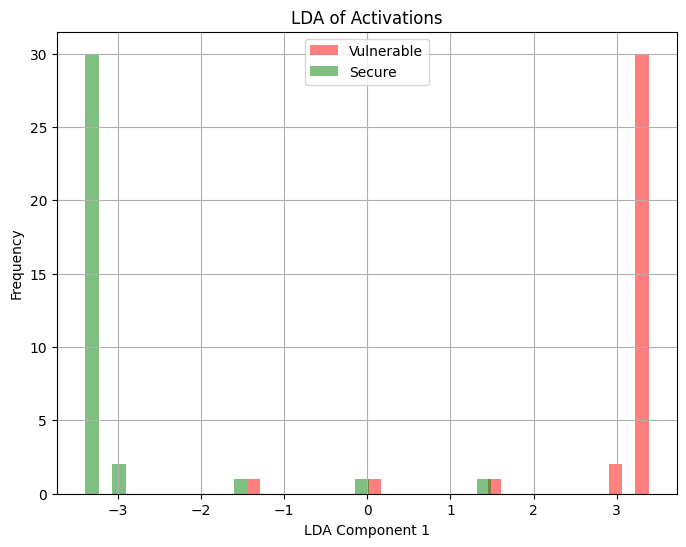

2026-01-28 04:38:56 [info     ] Layer 0, CWE CWE-476: LDA Fisher Score = 85.4632, Probing Accuracy = 0.2931


Loading:  95%|█████████▍| 2372/2500 [00:02<00:00, 674.87 lines/s] 

2026-01-28 04:38:59 [error    ] JSON decoding error: unexpected end of data: line 1 column 155701 (char 155700)


Loading:  95%|█████████▌| 2383/2500 [00:02<00:00, 865.40 lines/s]


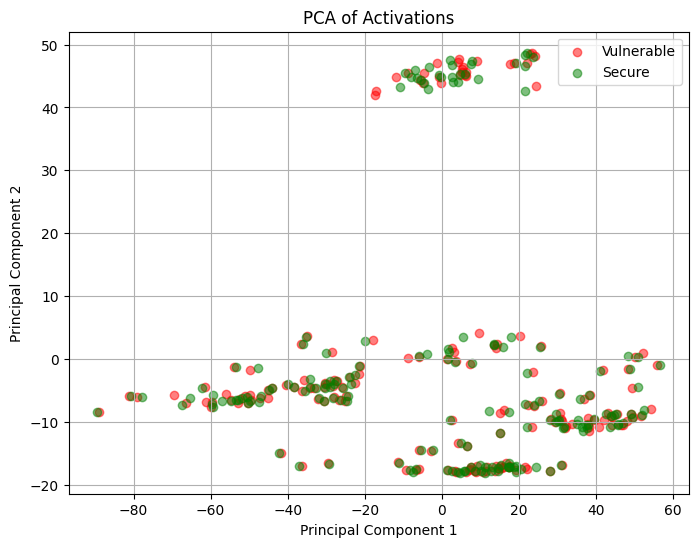

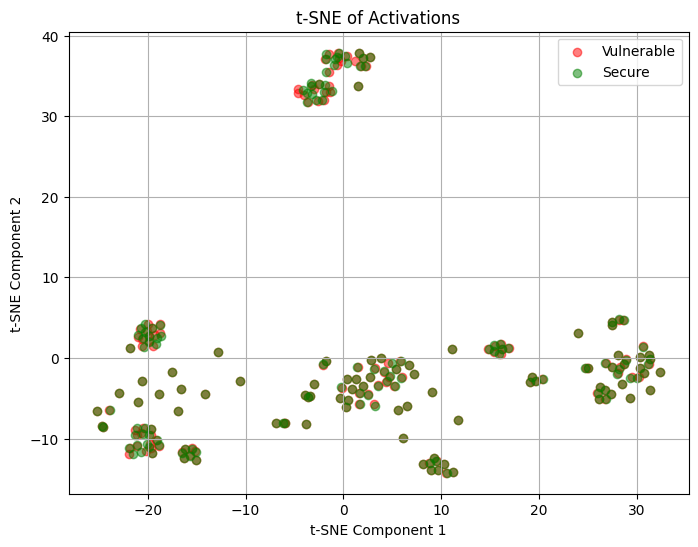

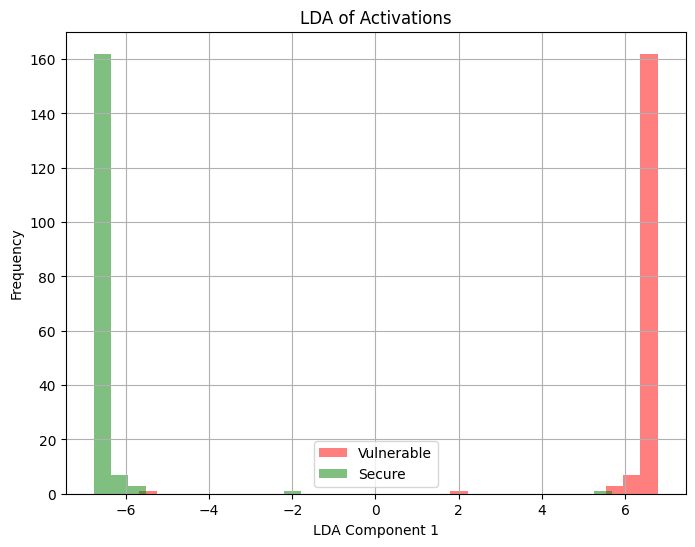

2026-01-28 04:39:01 [info     ] Layer 0, CWE CWE-434: LDA Fisher Score = 58.0001, Probing Accuracy = 0.2167


Loading:  95%|█████████▍| 2365/2500 [00:02<00:00, 1042.81 lines/s]

2026-01-28 04:39:03 [error    ] JSON decoding error: unexpected end of data: line 1 column 155701 (char 155700)


Loading:  95%|█████████▌| 2383/2500 [00:02<00:00, 1079.16 lines/s]


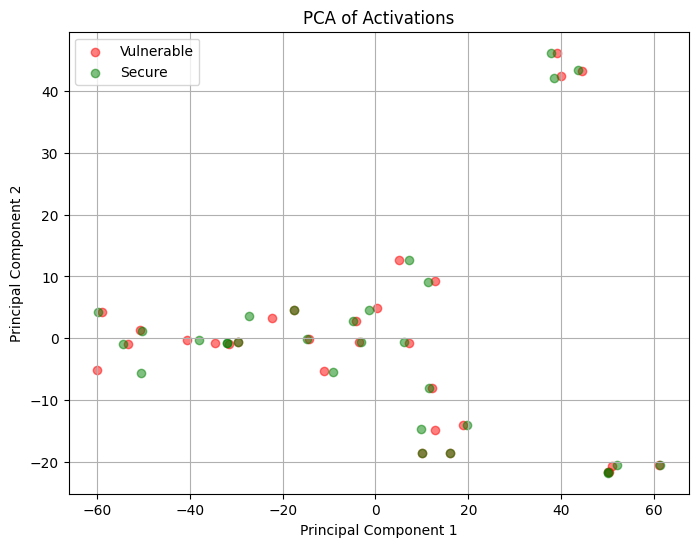

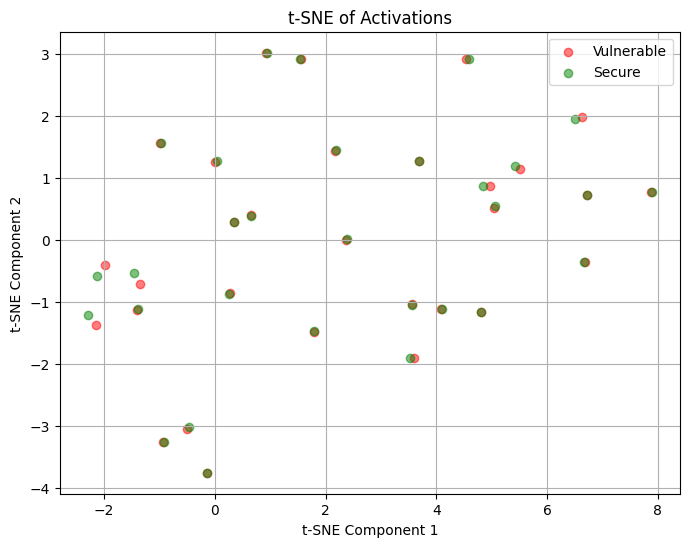

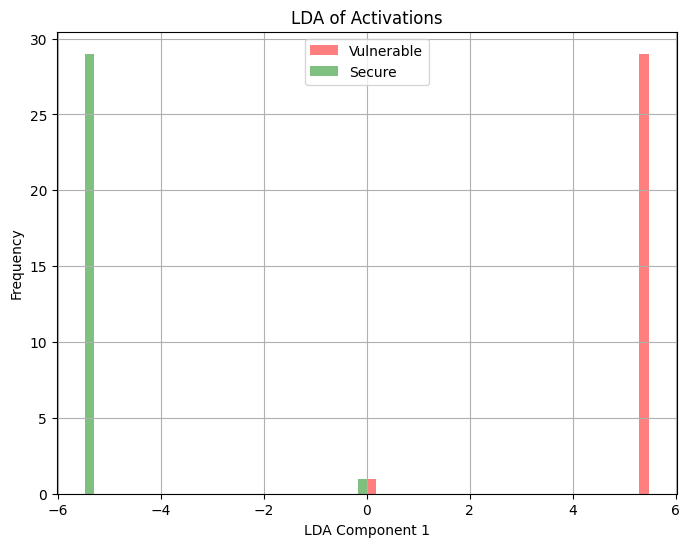

2026-01-28 04:39:03 [info     ] Layer 0, CWE CWE-401: LDA Fisher Score = 8.5444, Probing Accuracy = 0.2598


Loading:  92%|█████████▏| 2304/2500 [00:02<00:00, 891.38 lines/s] 

2026-01-28 04:39:06 [error    ] JSON decoding error: unexpected end of data: line 1 column 155701 (char 155700)


Loading:  95%|█████████▌| 2383/2500 [00:02<00:00, 1045.72 lines/s]


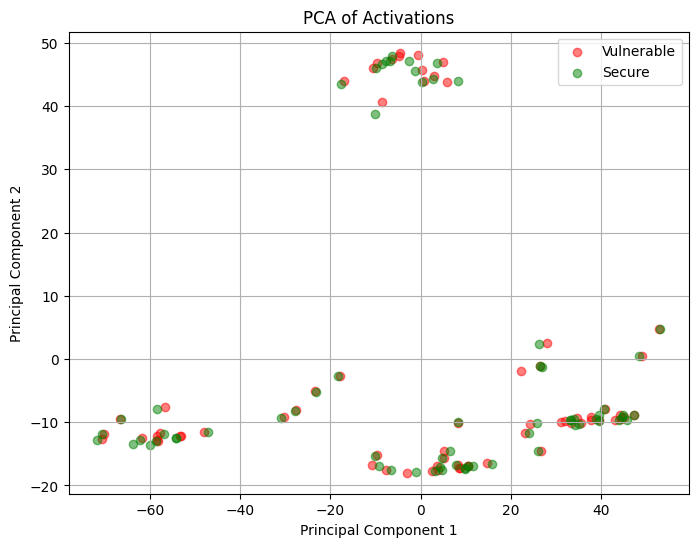

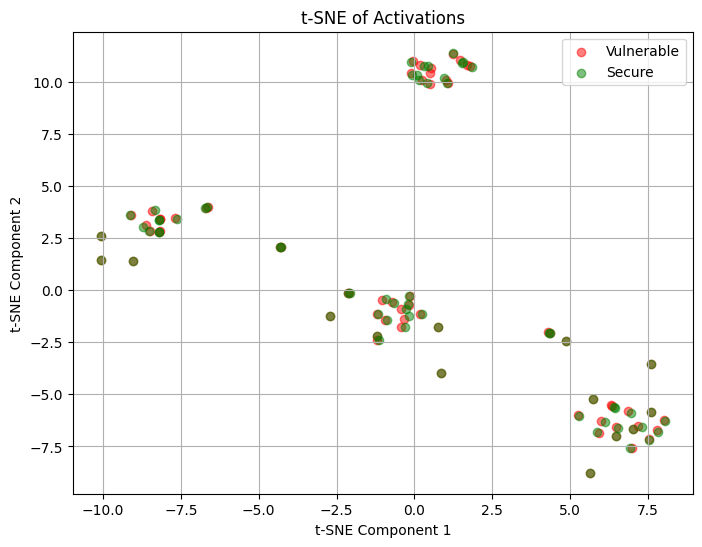

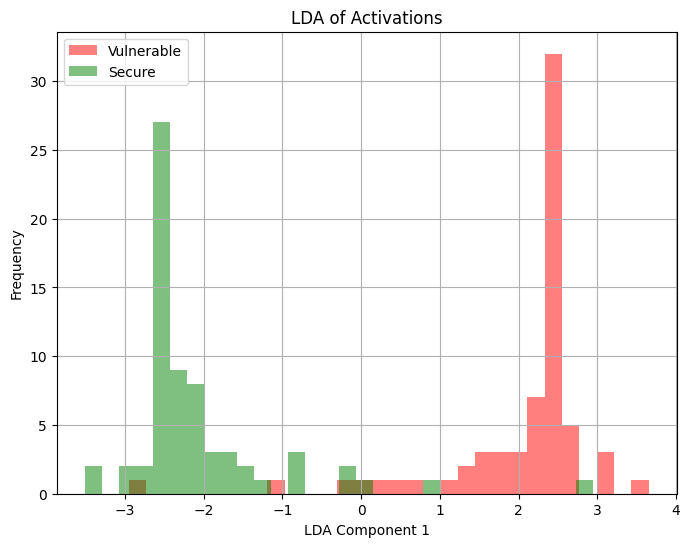

2026-01-28 04:39:07 [info     ] Layer 0, CWE CWE-119: LDA Fisher Score = 160.0658, Probing Accuracy = 0.3249


Loading:  92%|█████████▏| 2310/2500 [00:02<00:00, 975.90 lines/s]

2026-01-28 04:39:10 [error    ] JSON decoding error: unexpected end of data: line 1 column 155701 (char 155700)


Loading:  95%|█████████▌| 2383/2500 [00:02<00:00, 805.10 lines/s]


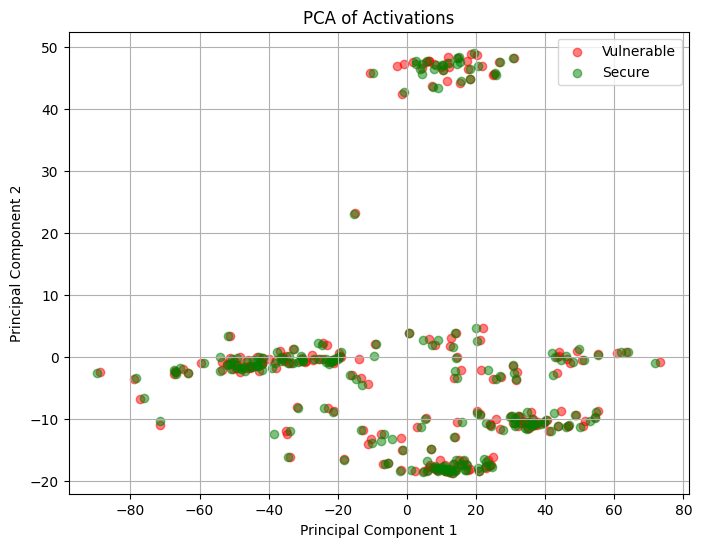

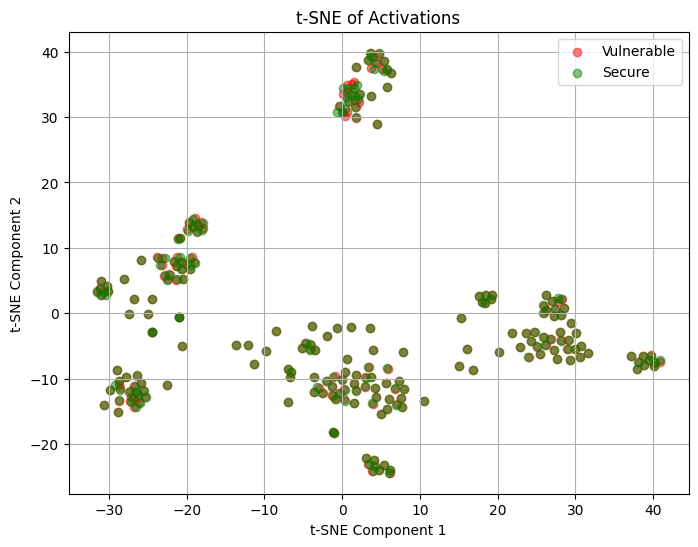

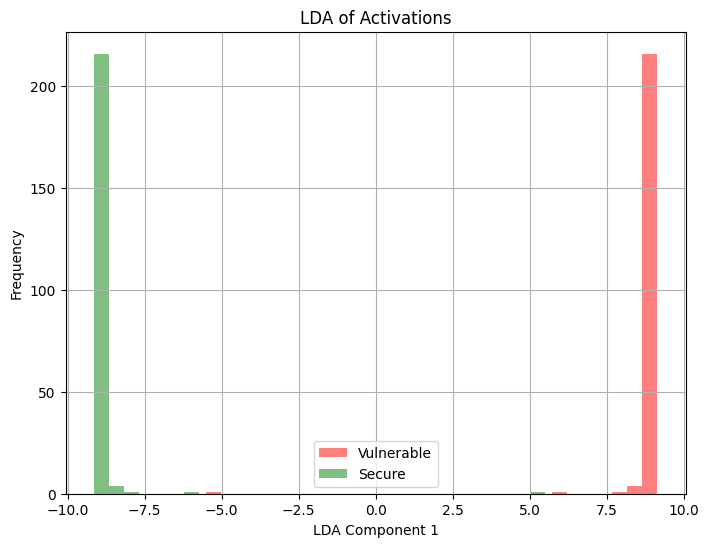

2026-01-28 04:39:12 [info     ] Layer 0, CWE CWE-415: LDA Fisher Score = 11.9532, Probing Accuracy = 0.2909


Loading:  92%|█████████▏| 2290/2500 [00:02<00:00, 1088.88 lines/s]

2026-01-28 04:39:14 [error    ] JSON decoding error: unexpected end of data: line 1 column 155701 (char 155700)


Loading:  95%|█████████▌| 2383/2500 [00:02<00:00, 1101.03 lines/s]


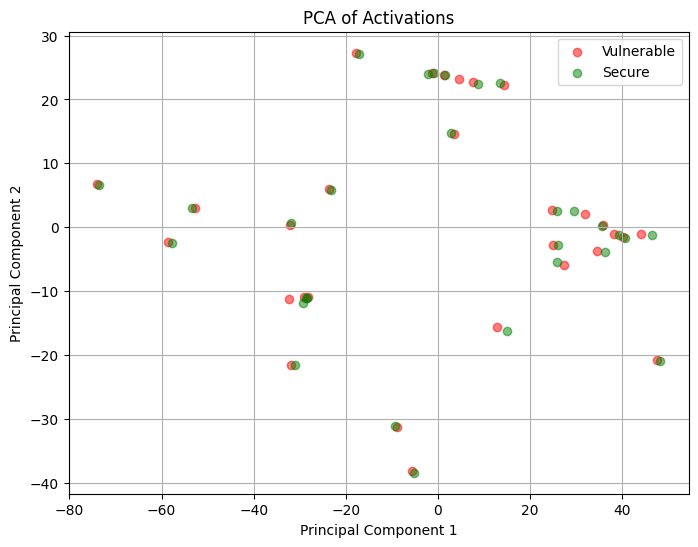

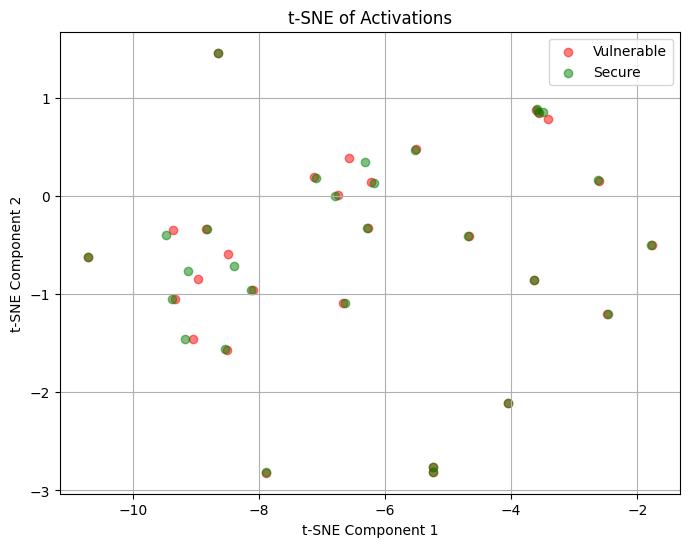

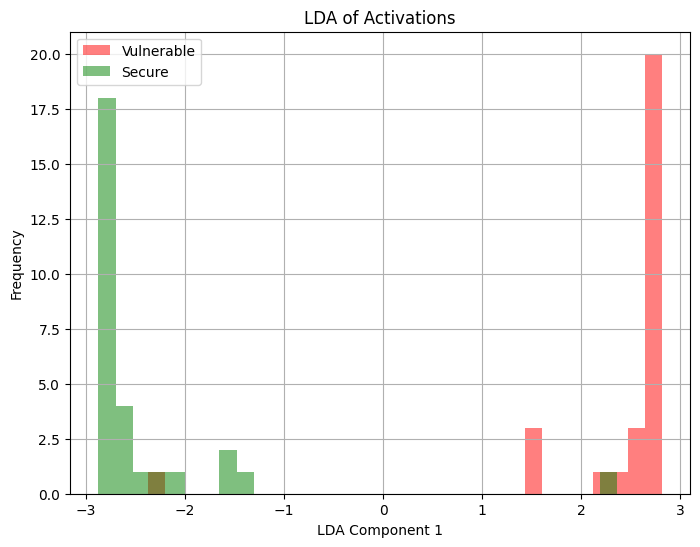

2026-01-28 04:39:15 [info     ] Layer 0, CWE CWE-189: LDA Fisher Score = 5.7488, Probing Accuracy = 0.2057


Loading:  91%|█████████ | 2272/2500 [00:02<00:00, 1189.20 lines/s]

2026-01-28 04:39:17 [error    ] JSON decoding error: unexpected end of data: line 1 column 155701 (char 155700)


Loading:  95%|█████████▌| 2383/2500 [00:02<00:00, 1093.91 lines/s]


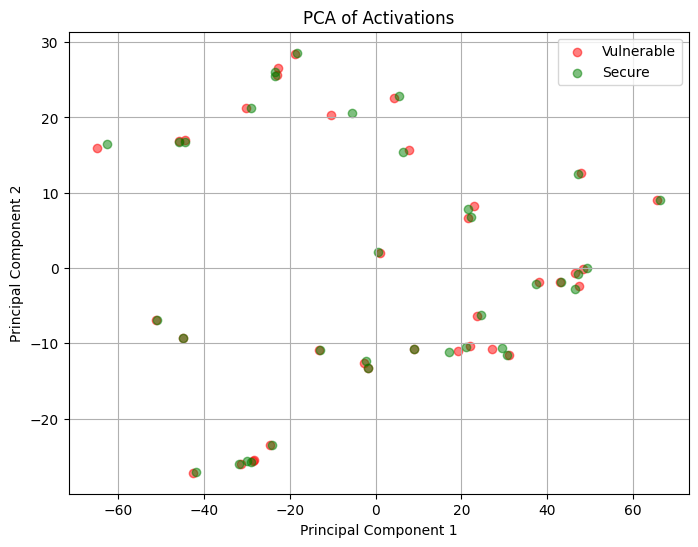

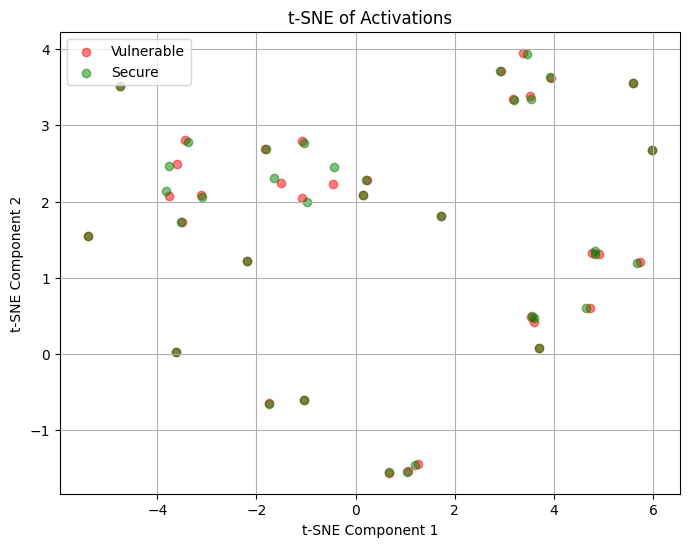

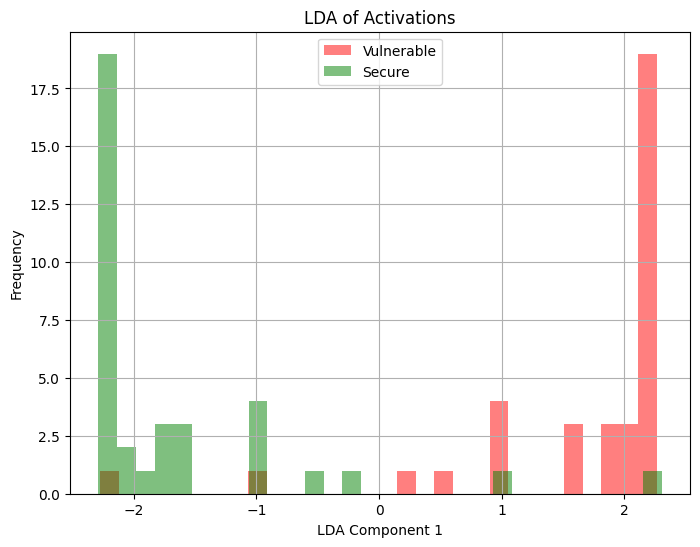

2026-01-28 04:39:18 [info     ] Layer 0, CWE CWE-264: LDA Fisher Score = 14.4269, Probing Accuracy = 0.1648


Loading:  95%|█████████▍| 2373/2500 [00:02<00:00, 1181.66 lines/s]

2026-01-28 04:39:20 [error    ] JSON decoding error: unexpected end of data: line 1 column 155701 (char 155700)


Loading:  95%|█████████▌| 2383/2500 [00:02<00:00, 1070.49 lines/s]


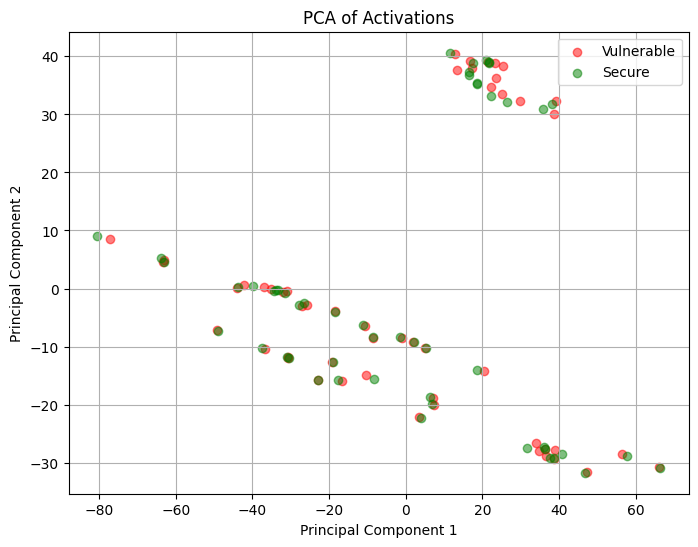

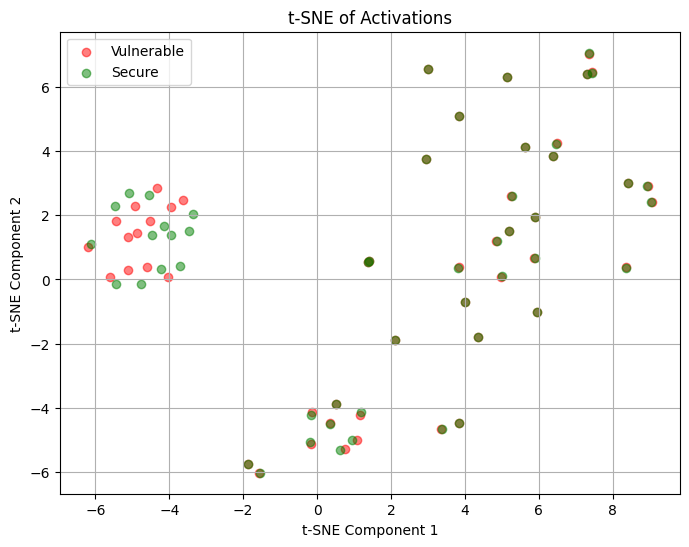

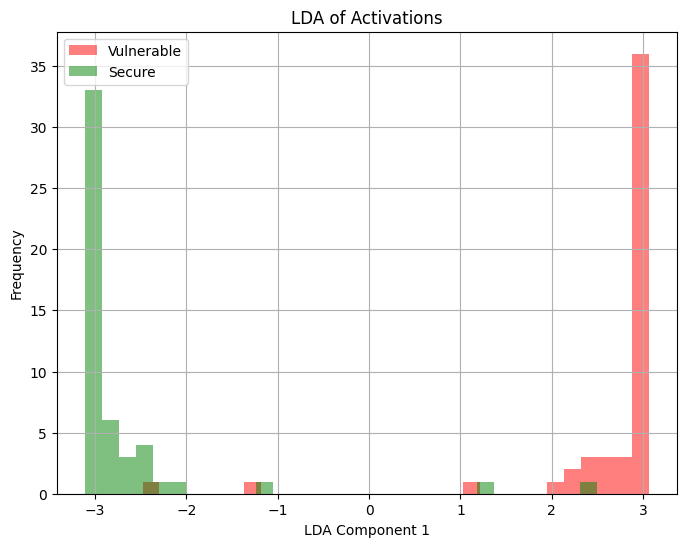

2026-01-28 04:39:21 [info     ] Layer 0, CWE CWE-399: LDA Fisher Score = 32.5296, Probing Accuracy = 0.2290


Loading:  93%|█████████▎| 2330/2500 [00:02<00:00, 1154.88 lines/s]

2026-01-28 04:39:23 [error    ] JSON decoding error: unexpected end of data: line 1 column 155701 (char 155700)


Loading:  95%|█████████▌| 2383/2500 [00:02<00:00, 1049.22 lines/s]


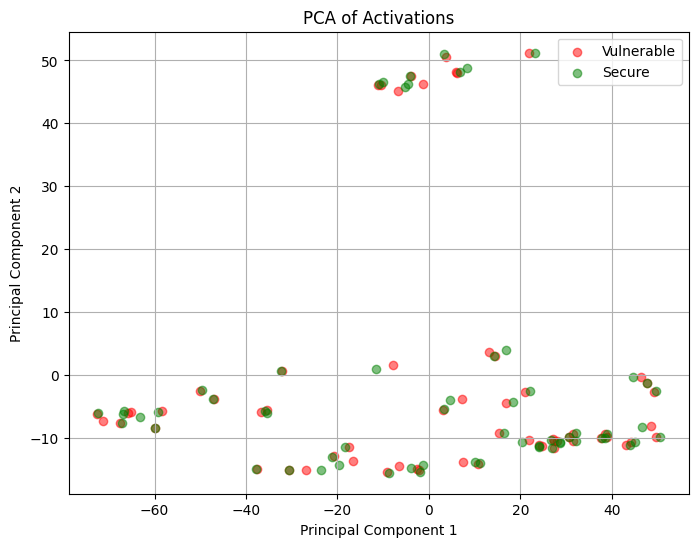

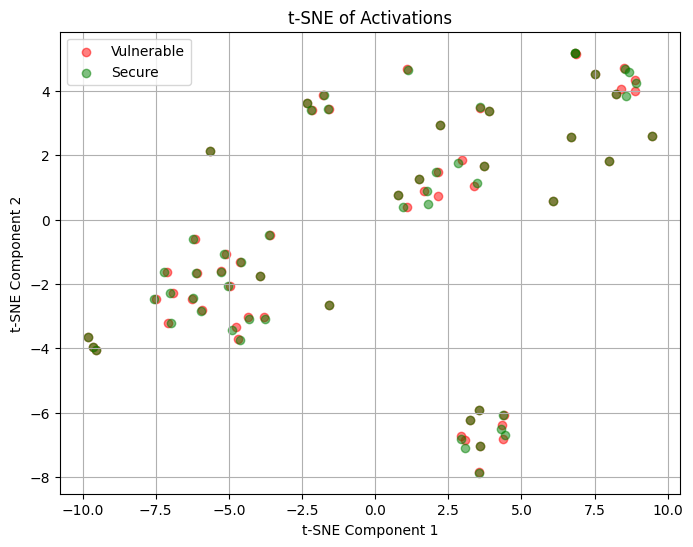

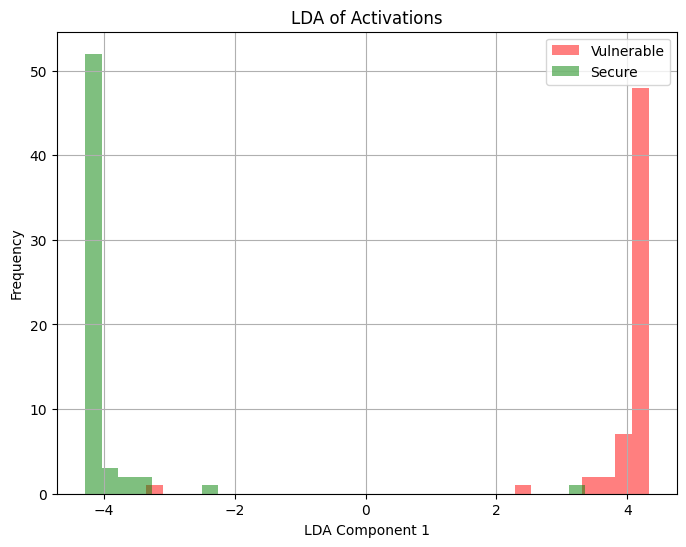

KeyError: ('0', 'ALL')

In [30]:
files = sorted(glob.glob(f"../artifacts/activations/{RUN_ID}/activations_layer_*"))

def get_data(files: list, layer_id: int, cwe: str):
    # Read file and extract data for given layer_id and cwe
    for file in files:
        if f"layer_{layer_id}_" in file:
            activation_file = file
            break
    else:
        raise ValueError(f"Layer {layer_id} not found in files.")
    

    cwe_tensor_map: Dict[str, VulnerabilityData] = {}
    vulnerable_features = torch.tensor([])
    safe_features = torch.tensor([])
    # Loads activations.
    with open(activation_file, "r") as f:
        for line in tqdm(f, desc="Loading", unit=" lines", total=2500):
            try:
                data = orjson.loads(line)
            except orjson.JSONDecodeError as e:
                logger.error(f"JSON decoding error: {e}")
                # skip to the next file
                break
            _cwe = data["cwe"]
            if _cwe != cwe:
                continue
            if cwe not in cwe_tensor_map:
                cwe_tensor_map[cwe] = VulnerabilityData(
                    vulnerable=torch.tensor([]),
                    secure=torch.tensor([]),
                )

            activations = ActivationsSchema(**data)
            # print(f"Vuln ID: {activations.vuln_id}, Layer: {activations.layer}")
            vuln_tensor = torch.tensor(activations.vulnerable)
            safe_tensor = torch.tensor(activations.secure)



            vulnerable_features = torch.cat(
                (vulnerable_features, vuln_tensor.unsqueeze(0)), dim=0
            )
            safe_features = torch.cat((safe_features, safe_tensor.unsqueeze(0)), dim=0)

            cwe_tensor_map[cwe] = VulnerabilityData(
                vulnerable=torch.cat(
                    (cwe_tensor_map[cwe].vulnerable, vuln_tensor.unsqueeze(0)), dim=0
                ),
                secure=torch.cat(
                    (cwe_tensor_map[cwe].secure, safe_tensor.unsqueeze(0)), dim=0
                ),
            )


    return cwe_tensor_map[cwe]


def plot_pca(secure_features: torch.Tensor, vulnerable_features: torch.Tensor, label_secure="Secure", label_vulnerable="Vulnerable"):
    from sklearn.decomposition import PCA
    import matplotlib.pyplot as plt

    # Combine features and labels
    vuln_labels = torch.ones(vulnerable_features.size(0), dtype=torch.float32)
    safe_labels = torch.zeros(secure_features.size(0), dtype=torch.float32)
    all_features = torch.cat((vulnerable_features, secure_features), dim=0).float()
    all_labels = torch.cat((vuln_labels, safe_labels), dim=0).long()

    # PCA
    pca = PCA(n_components=2)
    proj = pca.fit_transform(all_features.numpy())

    vuln_proj = proj[: len(vulnerable_features)]
    safe_proj = proj[len(vulnerable_features):]

    plt.figure(figsize=(8, 6))
    plt.scatter(
        vuln_proj[:, 0], vuln_proj[:, 1], c="r", label=label_vulnerable, alpha=0.5
    )
    plt.scatter(safe_proj[:, 0], safe_proj[:, 1], c="g", label=label_secure, alpha=0.5)
    plt.title("PCA of Activations")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.legend()
    plt.grid()
    plt.show()


def plot_lda(secure_features: torch.Tensor, vulnerable_features: torch.Tensor, label_secure="Secure", label_vulnerable="Vulnerable"):
    from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
    import matplotlib.pyplot as plt

    # Combine features and labels
    vuln_labels = torch.ones(vulnerable_features.size(0), dtype=torch.float32)
    safe_labels = torch.zeros(secure_features.size(0), dtype=torch.float32)
    all_features = torch.cat((vulnerable_features, secure_features), dim=0).float()
    all_labels = torch.cat((vuln_labels, safe_labels), dim=0).long()

    # LDA
    lda = LinearDiscriminantAnalysis(n_components=1)
    proj = lda.fit_transform(all_features.numpy(), all_labels.numpy())

    vuln_proj = proj[: len(vulnerable_features)]
    safe_proj = proj[len(vulnerable_features):]

    plt.figure(figsize=(8, 6))
    plt.hist(vuln_proj, bins=30, alpha=0.5, label=label_vulnerable, color="r")
    plt.hist(safe_proj, bins=30, alpha=0.5, label=label_secure, color="g")
    plt.title("LDA of Activations")
    plt.xlabel("LDA Component 1")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid()
    plt.show()


def plot_tsne(secure_features: torch.Tensor, vulnerable_features: torch.Tensor, label_secure="Secure", label_vulnerable="Vulnerable"):
    from sklearn.manifold import TSNE
    import matplotlib.pyplot as plt

    # Combine features and labels
    vuln_labels = torch.ones(vulnerable_features.size(0), dtype=torch.float32)
    safe_labels = torch.zeros(secure_features.size(0), dtype=torch.float32)
    all_features = torch.cat((vulnerable_features, secure_features), dim=0).float()
    all_labels = torch.cat((vuln_labels, safe_labels), dim=0).long()

    # t-SNE
    tsne = TSNE(n_components=2, random_state=42)
    proj = tsne.fit_transform(all_features.numpy())

    vuln_proj = proj[: len(vulnerable_features)]
    safe_proj = proj[len(vulnerable_features):]

    plt.figure(figsize=(8, 6))
    plt.scatter(
        vuln_proj[:, 0], vuln_proj[:, 1], c="r", label=label_vulnerable, alpha=0.5
    )
    plt.scatter(safe_proj[:, 0], safe_proj[:, 1], c="g", label=label_secure, alpha=0.5)
    plt.title("t-SNE of Activations")
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.legend()
    plt.grid()
    plt.show()

for key in FisherScoreMap:
    if key == "ALL":
        continue
    logger.info(f"Layer {key[0]}, CWE {key[1]}: LDA Fisher Score = {FisherScoreMap[key]:.4f}, Probing Accuracy = {ProbingDataMap[key]:.4f}")
    layer_id = int(key[0])
    cwe = key[1]
    data = get_data(files, layer_id, cwe)
    plot_pca(data.secure, data.vulnerable, label_secure="Secure", label_vulnerable="Vulnerable")
    plot_tsne(data.secure, data.vulnerable, label_secure="Secure", label_vulnerable="Vulnerable")
    plot_lda(data.secure, data.vulnerable, label_secure="Secure", label_vulnerable="Vulnerable")

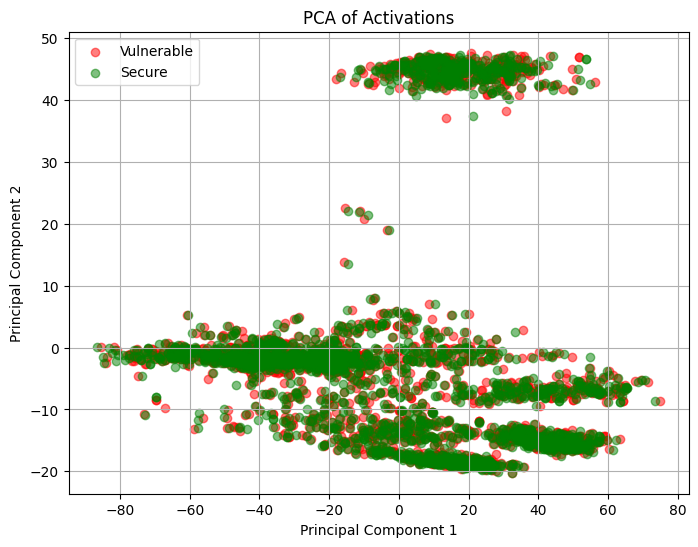

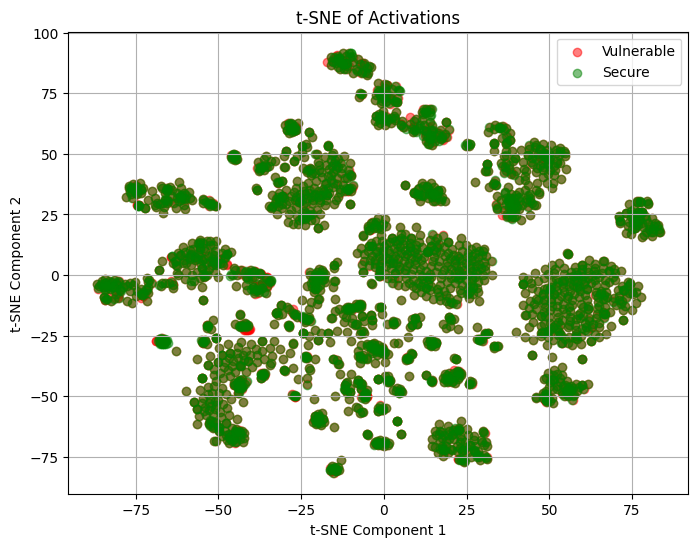

In [31]:
plot_pca(all_safe_features["layer_0"], all_vulnerable_features["layer_0"], label_secure="Secure", label_vulnerable="Vulnerable")

plot_tsne(all_safe_features["layer_0"], all_vulnerable_features["layer_0"], label_secure="Secure", label_vulnerable="Vulnerable")


# CWES with CodeLLAMA

In [32]:
RUN_ID = "run_20260128_150635"

FisherScoreMap: Dict[Tuple[str, str], float] = {}
ProbingDataMap: Dict[Tuple[str, str], float] = {}
from typing import List
from collections import defaultdict

all_vulnerable_features: Dict[str, List[float]] = defaultdict(list)
all_safe_features : Dict[str, List[float]] = defaultdict(list)

for activation_file in files:
    logger.info("Processing file.", file=activation_file)

    cwe_tensor_map: Dict[str, VulnerabilityData] = {}
    vulnerable_features = torch.tensor([])
    safe_features = torch.tensor([])
    
    # Loads activations.
    with open(activation_file, "r") as f: 
        for line in tqdm(f, desc="Loading", unit=" lines", total=2500):
            try:
                data = orjson.loads(line)
            except orjson.JSONDecodeError as e:
                logger.error(f"JSON decoding error: {e}")
                # skip to the next file
                break
            
            cwe = data["cwe"]
            if cwe not in cwe_tensor_map:
                cwe_tensor_map[cwe] = VulnerabilityData(
                    vulnerable=torch.tensor([]),
                    secure=torch.tensor([]),
                )

            activations = ActivationsSchema(**data)
            vuln_tensor = torch.tensor(activations.vulnerable)
            safe_tensor = torch.tensor(activations.secure)


            vulnerable_features = torch.cat(
                (vulnerable_features, vuln_tensor.unsqueeze(0)), dim=0
            )
            safe_features = torch.cat((safe_features, safe_tensor.unsqueeze(0)), dim=0)
            

            cwe_tensor_map[cwe] = VulnerabilityData(
                vulnerable=torch.cat(
                    (cwe_tensor_map[cwe].vulnerable, vuln_tensor.unsqueeze(0)), dim=0
                ),
                secure=torch.cat(
                    (cwe_tensor_map[cwe].secure, safe_tensor.unsqueeze(0)), dim=0
                ),
            )

        print("Vulnerable Features Shape:", vulnerable_features.shape , "Safe Features Shape:", safe_features.shape)
        print("CWE:", cwe, "Vulnerable Shape:", vulnerable_features.shape, "Safe Shape:", safe_features.shape)
    
        all_vulnerable_features[
            "layer_" + activation_file.split("layer_")[1].split("_")[0]
        ] = torch.tensor(vulnerable_features)
        all_safe_features[
            "layer_" + activation_file.split("layer_")[1].split("_")[0]
        ]= torch.tensor(safe_features)
        

    # Save for later reuse
    layer_id = activation_file.split("layer_")[1].split("_")[0]
    torch.save(vulnerable_features, f"../artifacts/activations/{RUN_ID}/vulnerable_layer_{layer_id}.pt")
    torch.save(safe_features, f"../artifacts/activations/{RUN_ID}/safe_layer_{layer_id}.pt")

2026-01-28 15:29:39 [info     ] Processing file.               file=../artifacts/activations/run_20260127_202722/activations_layer_0_sae_blocks.0.hook_resid_post_component_hook_resid_post.hook_sae_acts_post.jsonl


Loading:  95%|█████████▌| 2383/2500 [02:48<00:14,  7.94 lines/s]

2026-01-28 15:32:27 [error    ] JSON decoding error: unexpected end of data: line 1 column 155701 (char 155700)


Loading:  95%|█████████▌| 2383/2500 [02:48<00:08, 14.15 lines/s]
/var/folders/s4/2zl3nz4j225gfbx8fkbdv9sm0000gq/T/ipykernel_7310/3555801599.py:60: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ] = torch.tensor(vulnerable_features)
/var/folders/s4/2zl3nz4j225gfbx8fkbdv9sm0000gq/T/ipykernel_7310/3555801599.py:63: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ]= torch.tensor(safe_features)


Vulnerable Features Shape: torch.Size([2383, 16384]) Safe Features Shape: torch.Size([2383, 16384])
CWE: CWE-476 Vulnerable Shape: torch.Size([2383, 16384]) Safe Shape: torch.Size([2383, 16384])


In [33]:
for key, data in tqdm(cwe_tensor_map.items()):
    # Compute LDA Fisher Score for this layer and CWE
    fisher_score = compute_lda_fisher_scores(data.secure, data.vulnerable)
    # logger.info(f"  LDA Fisher Score for CWE {key}: {fisher_score:.4f}")
    FisherScoreMap[(layer_id, key)] = fisher_score
    probe_score = train_small_mlp_kfold(data.secure, data.vulnerable, k=5)
    ProbingDataMap[(layer_id, key)] = probe_score


fisher_score = compute_lda_fisher_scores(safe_features, vulnerable_features)
FisherScoreMap[(layer_id, "ALL")] = fisher_score

100%|██████████| 25/25 [02:45<00:00,  6.62s/it]


In [36]:
FisherScoreMap

{('0', 'CWE-200'): 25.795289649956906,
 ('0', 'CWE-400'): 46.516385911549825,
 ('0', 'CWE-125'): 113.13271030561204,
 ('0', 'CWE-416'): 7.055609738227705,
 ('0', 'CWE-89'): 9.473184065351631,
 ('0', 'CWE-20'): 19.81509614159655,
 ('0', 'CWE-369'): 27.117368896728863,
 ('0', 'CWE-78'): 16.286262635150887,
 ('0', 'CWE-190'): 9.873783135084993,
 ('0', 'CWE-79'): 14.193112559253576,
 ('0', 'CWE-787'): 176.53394685058342,
 ('0', 'CWE-352'): 25.290492207617955,
 ('0', 'CWE-22'): 7.835503993240612,
 ('0', 'CWE-94'): 12.564407684757482,
 ('0', 'CWE-362'): 8.005993456748742,
 ('0', 'CWE-287'): 22.032203990631295,
 ('0', 'CWE-120'): 19.08885895800825,
 ('0', 'CWE-476'): 85.46323650819372,
 ('0', 'CWE-434'): 58.000106828288736,
 ('0', 'CWE-401'): 8.544435575734719,
 ('0', 'CWE-119'): 160.06584778445549,
 ('0', 'CWE-415'): 11.953215820807113,
 ('0', 'CWE-189'): 5.748840966505891,
 ('0', 'CWE-264'): 14.426864327860436,
 ('0', 'CWE-399'): 32.5295674047461,
 ('0', 'ALL'): 5.145404659366511}

In [37]:
ProbingDataMap

{('0', 'CWE-200'): 0.2604636591478696,
 ('0', 'CWE-400'): 0.24615384615384617,
 ('0', 'CWE-125'): 0.2281516309138995,
 ('0', 'CWE-416'): 0.2739024390243902,
 ('0', 'CWE-89'): 0.17632183908045979,
 ('0', 'CWE-20'): 0.2531886024423338,
 ('0', 'CWE-369'): 0.27316017316017316,
 ('0', 'CWE-78'): 0.2961904761904762,
 ('0', 'CWE-190'): 0.33588709677419354,
 ('0', 'CWE-79'): 0.28059826670394183,
 ('0', 'CWE-787'): 0.22903225806451616,
 ('0', 'CWE-352'): 0.13333333333333333,
 ('0', 'CWE-22'): 0.2128205128205128,
 ('0', 'CWE-94'): 0.1282051282051282,
 ('0', 'CWE-362'): 0.21108374384236456,
 ('0', 'CWE-287'): 0.23846153846153845,
 ('0', 'CWE-120'): 0.2,
 ('0', 'CWE-476'): 0.29018633540372674,
 ('0', 'CWE-434'): 0.06666666666666667,
 ('0', 'CWE-401'): 0.23789173789173787,
 ('0', 'CWE-119'): 0.2736579275905119,
 ('0', 'CWE-415'): 0.20303030303030303,
 ('0', 'CWE-189'): 0.15238095238095237,
 ('0', 'CWE-264'): 0.07857142857142857,
 ('0', 'CWE-399'): 0.22933333333333333}

In [38]:
files = sorted(glob.glob(f"../artifacts/activations/{RUN_ID}/activations_layer_*"))

def get_data(files: list, layer_id: int, cwe: str):
    # Read file and extract data for given layer_id and cwe
    for file in files:
        if f"layer_{layer_id}_" in file:
            activation_file = file
            break
    else:
        raise ValueError(f"Layer {layer_id} not found in files.")
    

    cwe_tensor_map: Dict[str, VulnerabilityData] = {}
    vulnerable_features = torch.tensor([])
    safe_features = torch.tensor([])
    # Loads activations.
    with open(activation_file, "r") as f:
        for line in tqdm(f, desc="Loading", unit=" lines", total=2500):
            try:
                data = orjson.loads(line)
            except orjson.JSONDecodeError as e:
                logger.error(f"JSON decoding error: {e}")
                # skip to the next file
                break
            _cwe = data["cwe"]
            if _cwe != cwe:
                continue
            if cwe not in cwe_tensor_map:
                cwe_tensor_map[cwe] = VulnerabilityData(
                    vulnerable=torch.tensor([]),
                    secure=torch.tensor([]),
                )

            activations = ActivationsSchema(**data)
            # print(f"Vuln ID: {activations.vuln_id}, Layer: {activations.layer}")
            vuln_tensor = torch.tensor(activations.vulnerable)
            safe_tensor = torch.tensor(activations.secure)



            vulnerable_features = torch.cat(
                (vulnerable_features, vuln_tensor.unsqueeze(0)), dim=0
            )
            safe_features = torch.cat((safe_features, safe_tensor.unsqueeze(0)), dim=0)

            cwe_tensor_map[cwe] = VulnerabilityData(
                vulnerable=torch.cat(
                    (cwe_tensor_map[cwe].vulnerable, vuln_tensor.unsqueeze(0)), dim=0
                ),
                secure=torch.cat(
                    (cwe_tensor_map[cwe].secure, safe_tensor.unsqueeze(0)), dim=0
                ),
            )


    return cwe_tensor_map[cwe]


def plot_pca(secure_features: torch.Tensor, vulnerable_features: torch.Tensor, label_secure="Secure", label_vulnerable="Vulnerable"):
    from sklearn.decomposition import PCA
    import matplotlib.pyplot as plt

    # Combine features and labels
    vuln_labels = torch.ones(vulnerable_features.size(0), dtype=torch.float32)
    safe_labels = torch.zeros(secure_features.size(0), dtype=torch.float32)
    all_features = torch.cat((vulnerable_features, secure_features), dim=0).float()
    all_labels = torch.cat((vuln_labels, safe_labels), dim=0).long()

    # PCA
    pca = PCA(n_components=2)
    proj = pca.fit_transform(all_features.numpy())

    vuln_proj = proj[: len(vulnerable_features)]
    safe_proj = proj[len(vulnerable_features):]

    plt.figure(figsize=(8, 6))
    plt.scatter(
        vuln_proj[:, 0], vuln_proj[:, 1], c="r", label=label_vulnerable, alpha=0.5
    )
    plt.scatter(safe_proj[:, 0], safe_proj[:, 1], c="g", label=label_secure, alpha=0.5)
    plt.title("PCA of Activations")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.legend()
    plt.grid()
    plt.show()


def plot_lda(secure_features: torch.Tensor, vulnerable_features: torch.Tensor, label_secure="Secure", label_vulnerable="Vulnerable"):
    from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
    import matplotlib.pyplot as plt

    # Combine features and labels
    vuln_labels = torch.ones(vulnerable_features.size(0), dtype=torch.float32)
    safe_labels = torch.zeros(secure_features.size(0), dtype=torch.float32)
    all_features = torch.cat((vulnerable_features, secure_features), dim=0).float()
    all_labels = torch.cat((vuln_labels, safe_labels), dim=0).long()

    # LDA
    lda = LinearDiscriminantAnalysis(n_components=1)
    proj = lda.fit_transform(all_features.numpy(), all_labels.numpy())

    vuln_proj = proj[: len(vulnerable_features)]
    safe_proj = proj[len(vulnerable_features):]

    plt.figure(figsize=(8, 6))
    plt.hist(vuln_proj, bins=30, alpha=0.5, label=label_vulnerable, color="r")
    plt.hist(safe_proj, bins=30, alpha=0.5, label=label_secure, color="g")
    plt.title("LDA of Activations")
    plt.xlabel("LDA Component 1")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid()
    plt.show()


def plot_tsne(secure_features: torch.Tensor, vulnerable_features: torch.Tensor, label_secure="Secure", label_vulnerable="Vulnerable"):
    from sklearn.manifold import TSNE
    import matplotlib.pyplot as plt

    # Combine features and labels
    vuln_labels = torch.ones(vulnerable_features.size(0), dtype=torch.float32)
    safe_labels = torch.zeros(secure_features.size(0), dtype=torch.float32)
    all_features = torch.cat((vulnerable_features, secure_features), dim=0).float()
    all_labels = torch.cat((vuln_labels, safe_labels), dim=0).long()

    # t-SNE
    tsne = TSNE(n_components=2, random_state=42)
    proj = tsne.fit_transform(all_features.numpy())

    vuln_proj = proj[: len(vulnerable_features)]
    safe_proj = proj[len(vulnerable_features):]

    plt.figure(figsize=(8, 6))
    plt.scatter(
        vuln_proj[:, 0], vuln_proj[:, 1], c="r", label=label_vulnerable, alpha=0.5
    )
    plt.scatter(safe_proj[:, 0], safe_proj[:, 1], c="g", label=label_secure, alpha=0.5)
    plt.title("t-SNE of Activations")
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.legend()
    plt.grid()
    plt.show()

for key in FisherScoreMap:
    if key == "ALL":
        continue
    logger.info(f"Layer {key[0]}, CWE {key[1]}: LDA Fisher Score = {FisherScoreMap[key]:.4f}, Probing Accuracy = {ProbingDataMap[key]:.4f}")
    layer_id = int(key[0])
    cwe = key[1]
    data = get_data(files, layer_id, cwe)
    plot_pca(data.secure, data.vulnerable, label_secure="Secure", label_vulnerable="Vulnerable")
    plot_tsne(data.secure, data.vulnerable, label_secure="Secure", label_vulnerable="Vulnerable")
    plot_lda(data.secure, data.vulnerable, label_secure="Secure", label_vulnerable="Vulnerable")

2026-01-28 15:35:53 [info     ] Layer 0, CWE CWE-200: LDA Fisher Score = 25.7953, Probing Accuracy = 0.2605


Loading:   0%|          | 0/2500 [00:00<?, ? lines/s]


ValidationError: 1 validation error for ActivationsSchema
sae_config.model
  Input should be 'gpt2', 'google/gemma-2-2b', 'google/gemma-3-1b-pt', 'llama', 'meta-llama/Llama-3.1-8B-Instruct', 'meta-llama/Llama-3.2-1B-Instruct', 'meta-llama/Llama-3.1-8B' or 'pythia-70m-deduped' [type=enum, input_value='codellama/CodeLlama-7b-hf', input_type=str]
    For further information visit https://errors.pydantic.dev/2.11/v/enum

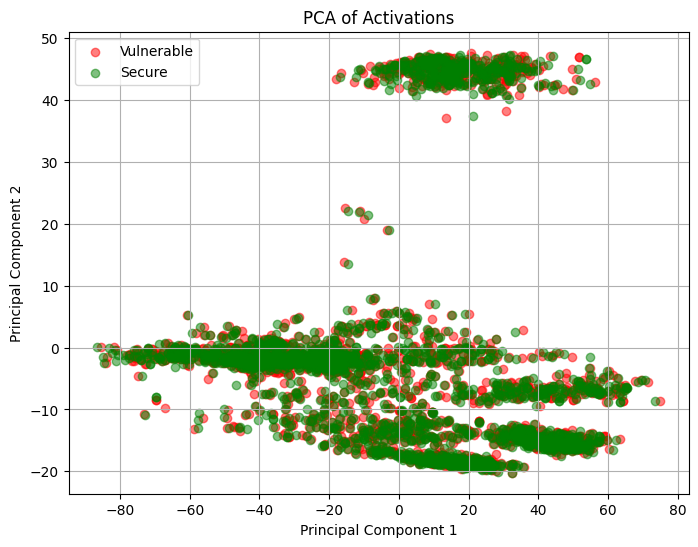

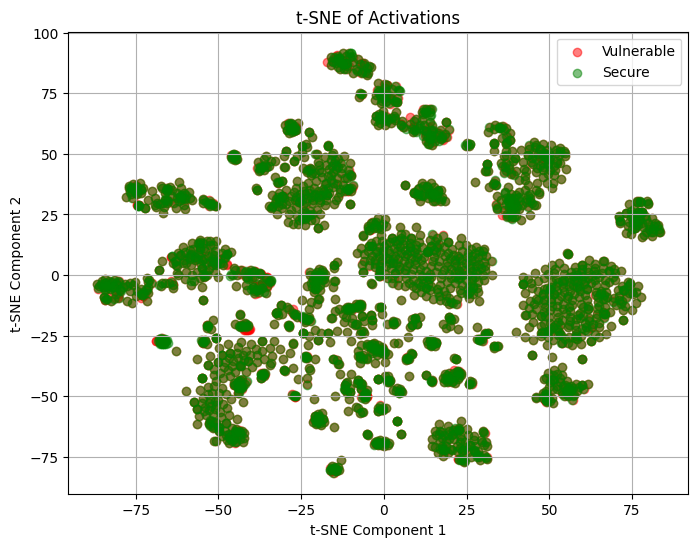

In [ ]:
plot_pca(all_safe_features["layer_0"], all_vulnerable_features["layer_0"], label_secure="Secure", label_vulnerable="Vulnerable")

plot_tsne(all_safe_features["layer_0"], all_vulnerable_features["layer_0"], label_secure="Secure", label_vulnerable="Vulnerable")


## Dump

In [ ]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def plot_pca_subplots(cwe_data_map: Dict[str, VulnerabilityData]):
    """Create subplots for each CWE"""
    n_cwes = len(cwe_data_map)
    n_cols = 3
    n_rows = (n_cwes + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten() if n_cwes > 1 else [axes]
    
    for idx, (cwe, data) in enumerate(cwe_data_map.items()):
        pca = PCA(n_components=2)
        
        # Fit PCA on combined data
        combined_data = torch.cat([data.vulnerable, data.secure], dim=0).numpy()
        pca_transformed = pca.fit_transform(combined_data)
        
        # Split back into vulnerable and safe
        vuln_size = data.vulnerable.shape[0]
        vuln_pca = pca_transformed[:vuln_size]
        safe_pca = pca_transformed[vuln_size:]
        
        ax = axes[idx]
        ax.scatter(
            vuln_pca[:, 0],
            vuln_pca[:, 1],
            c="red",
            label="Vulnerable",
            alpha=0.7,
        )
        ax.scatter(
            safe_pca[:, 0],
            safe_pca[:, 1],
            c="blue",
            label="Safe",
            alpha=0.7,
        )
        ax.set_xlabel("PCA Component 1")
        ax.set_ylabel("PCA Component 2")
        ax.set_title(f"{cwe}")
        ax.legend()
    
    # Hide unused subplots
    for idx in range(n_cwes, len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle("PCA of Sparse Autoencoder Activations by CWE", fontsize=16, y=1.00)
    plt.tight_layout()
    plt.show()


# Plot subplots for each CWE
print("Plotting PCA subplots for each CWE")
plot_pca_subplots(cwe_tensor_map)
